In [24]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math
import time

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

from torch import nn
from pfns import utils
from pfns.model import bar_distribution

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")

from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors import Batch
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

✓ Working directory: /Users/ruslanguliev/VU_RG
✓ Device: mps
✓ PyTorch: 2.10.0


In [25]:
# =============================================
# NAČTENÍ MODELU
# =============================================
checkpoint_path = os.path.join('models', 'pfn_gp_model_hps_distr.pth')

print(f"Loading: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

config = checkpoint['config']
num_features = config['num_features']
max_dataset_size = config['max_dataset_size']

criterion = checkpoint['criterion']
borders = criterion.borders.tolist()

model_config = MainConfig(
    priors=[AdhocPriorConfig(
        get_batch_methods=[get_batch_for_gp],
        prior_kwargs={'num_features': num_features, 'hyperparameters': config['hps']}
    )],
    optimizer=OptimizerConfig('adamw', lr=0.0003),
    model=TransformerConfig(
        criterion=BarDistributionConfig(full_support=True, borders=borders),
        emsize=512,
        nhead=8,
        nhid=1024,
        nlayers=6,
        features_per_group=1,
        attention_between_features=False,
        encoder=EncoderConfig(
            constant_normalization_mean=0.5,
            constant_normalization_std=math.sqrt(1/12)
        )
    ),
    batch_shape_sampler=BatchShapeSamplerConfig(
        batch_size=2,
        max_seq_len=max_dataset_size,
        min_num_features=num_features,
        max_num_features=num_features
    ),
    epochs=1,
    steps_per_epoch=1,
    num_workers=0,
)

print("Vytvářím strukturu modelu...")
dummy_result = train(model_config, device=device, reusable_config=False)
loaded_model = dummy_result['model']

loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.criterion = criterion
loaded_model.to(device)
loaded_model.eval()

# Defaultní HP pro experimenty
hps = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3}
hps_demo = hps

print(f"✓ Model načten (epocha {config['epochs']})")
print(f"  Parametrů: {sum(p.numel() for p in loaded_model.parameters()) / 1e6:.2f}M")
print(f"  Tento model byl trénován na DISTRIBUCI hyperparametrů")

Loading: models/pfn_gp_model_hps_distr.pth
Vytvářím strukturu modelu...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features, device='mps', hyperparameters=None, equidistant_x=False, fix_x=None, **kwargs)
), num_features=1, hyperparameters={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=120, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_si

/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


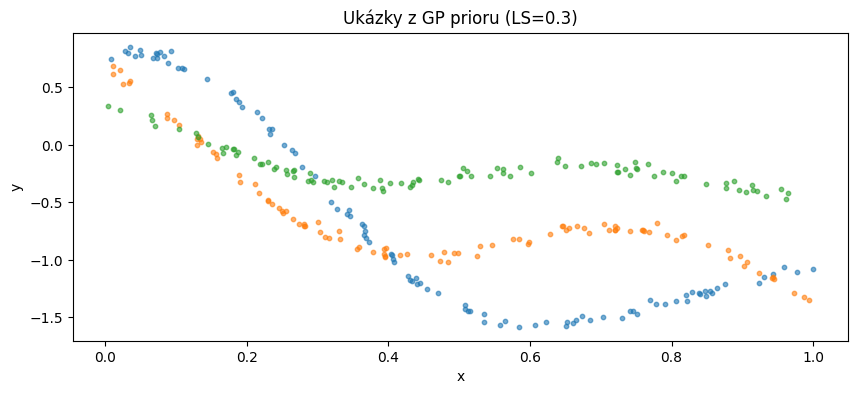

Batch shapes: x=torch.Size([3, 100, 1]), y=torch.Size([3, 100])


In [26]:
# =============================================
# GP PRIOR - Sampling funkce
# =============================================

# Tento model nemá fixní HP — musíme je vždy specifikovat sami

batch = get_batch_for_gp(batch_size=3, seq_len=100, num_features=1, hyperparameters=hps_demo)

plt.figure(figsize=(10, 4))
for i in range(len(batch.x)):
    plt.scatter(batch.x[i, :, 0].cpu().numpy(), batch.y[i, :].cpu().numpy(), alpha=0.6, s=10)
plt.title('Ukázky z GP prioru (LS=0.3)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
print(f"Batch shapes: x={batch.x.shape}, y={batch.y.shape}")

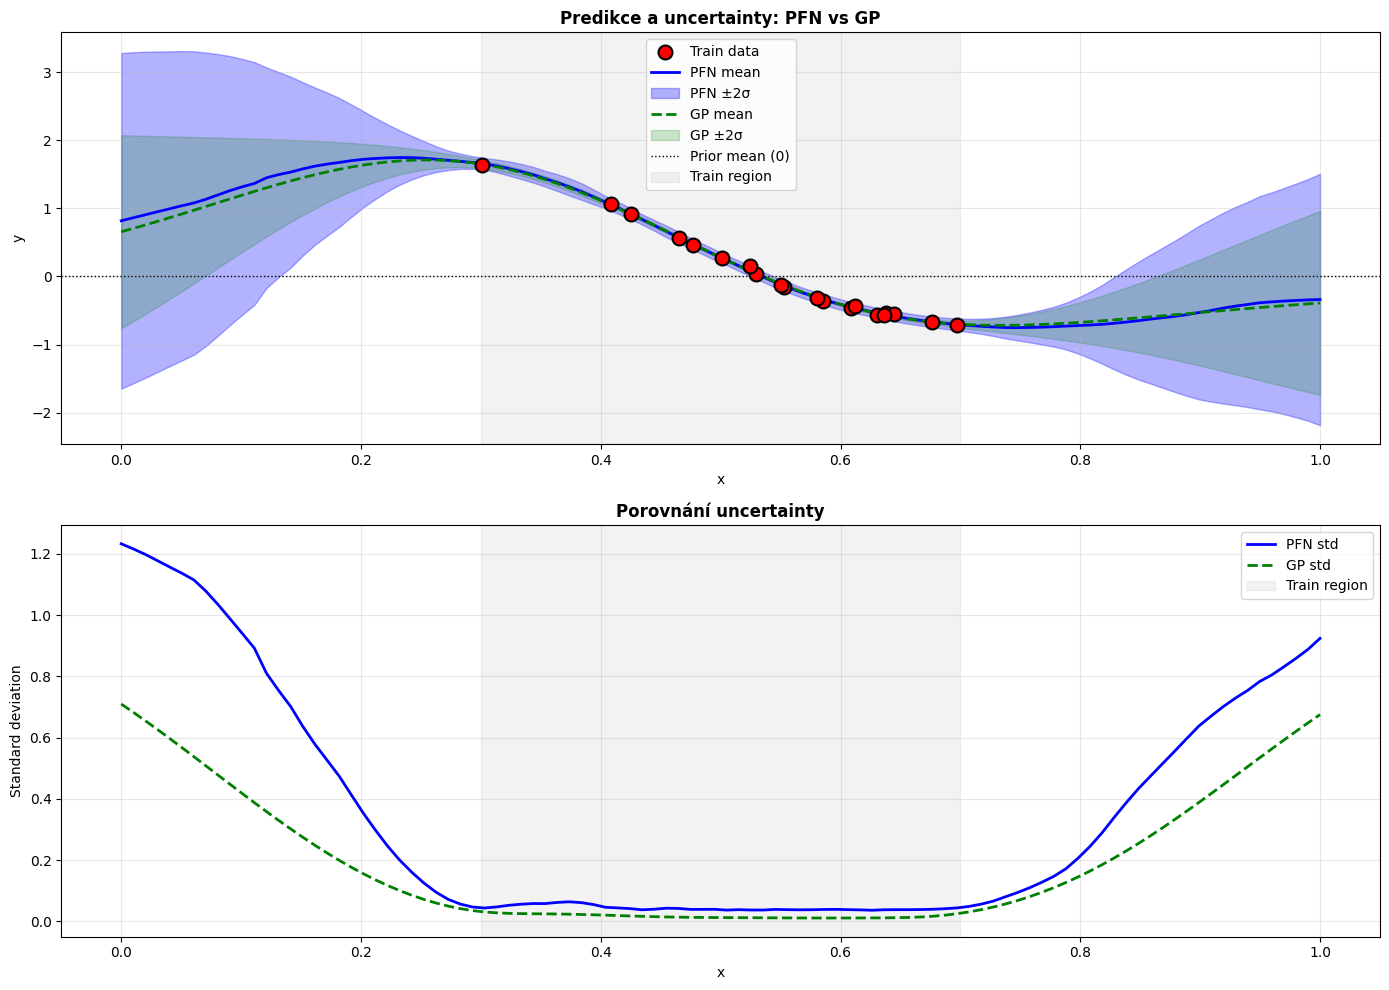


=== TEST 1: Konvergence mean funkce ===
Trial 0:
  Train data mean: -0.02
  PFN mean (far): 0.38, (near): 0.30
  GP mean (far):  0.31, (near): 0.31
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 1:
  Train data mean: -1.09
  PFN mean (far): -0.07, (near): -1.36
  GP mean (far):  -0.07, (near): -1.36
  PFN converges to train mean: False
  GP converges to train mean:  False
Trial 2:
  Train data mean: -1.09
  PFN mean (far): -0.07, (near): -1.36
  GP mean (far):  -0.07, (near): -1.36
  PFN converges to train mean: False
  GP converges to train mean:  False
Trial 3:
  Train data mean: -1.09
  PFN mean (far): -0.07, (near): -1.36
  GP mean (far):  -0.07, (near): -1.36
  PFN converges to train mean: False
  GP converges to train mean:  False
Trial 4:
  Train data mean: -1.09
  PFN mean (far): -0.07, (near): -1.36
  GP mean (far):  -0.07, (near): -1.36
  PFN converges to train mean: False
  GP converges to train mean:  False

=== TEST 2: Správnost variance ===

In [27]:
# =============================================
# EXPERIMENT 1: Konvergence k prioru a variance
# =============================================

def test_prior_convergence_and_variance(model, hps, n_trials=10):
    results = []

    for trial in range(n_trials):
        batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps)

        train_mask = (batch.x[0, :, 0] >= 0.3) & (batch.x[0, :, 0] <= 0.7)
        train_indices = torch.where(train_mask)[0][:20]

        train_x = batch.x[0, train_indices]
        train_y = batch.y[0, train_indices]

        test_x = torch.linspace(0, 1, 100).unsqueeze(1).to(batch.x.device)

        # PFN predikce
        with torch.no_grad():
            logits = model(train_x[None], train_y[None], test_x[None])

        pfn_means = model.criterion.mean(logits)[0].cpu().numpy()
        pfn_variance = model.criterion.variance(logits)[0].cpu().numpy()
        pfn_std = np.sqrt(pfn_variance)

        # GP predikce
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel

        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_mean, gp_std = gp.predict(test_x.cpu().numpy(), return_std=True)

        results.append({
            'test_x': test_x.cpu().numpy().flatten(),
            'train_x': train_x.cpu().numpy().flatten(),
            'train_y': train_y.cpu().numpy().flatten(),  # ← PŘIDÁNO!
            'pfn_mean': pfn_means,
            'pfn_std': pfn_std,
            'gp_mean': gp_mean,
            'gp_std': gp_std,
        })

    return results


# Spusť test pro různé HP
results = test_prior_convergence_and_variance(loaded_model, hps_demo, n_trials=5)

# Vizualizace jednoho příkladu
res = results[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Mean + uncertainty bands
ax = axes[0]

# Train data
ax.scatter(res['train_x'], res['train_y'],
           c='red', s=100, zorder=10, label='Train data', marker='o', edgecolors='black', linewidths=1.5)

# PFN prediction
ax.plot(res['test_x'], res['pfn_mean'], 'b-', lw=2, label='PFN mean')
ax.fill_between(res['test_x'],
                 res['pfn_mean'] - 2*res['pfn_std'],
                 res['pfn_mean'] + 2*res['pfn_std'],
                 alpha=0.3, color='blue', label='PFN ±2σ')

# GP prediction
ax.plot(res['test_x'], res['gp_mean'], 'g--', lw=2, label='GP mean')
ax.fill_between(res['test_x'],
                 res['gp_mean'] - 2*res['gp_std'],
                 res['gp_mean'] + 2*res['gp_std'],
                 alpha=0.2, color='green', label='GP ±2σ')

# Prior mean (0)
ax.axhline(y=0, color='black', linestyle=':', lw=1, label='Prior mean (0)')

# Zvýrazni train region
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Predikce a uncertainty: PFN vs GP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Comparison of uncertainties
ax = axes[1]

ax.plot(res['test_x'], res['pfn_std'], 'b-', lw=2, label='PFN std')
ax.plot(res['test_x'], res['gp_std'], 'g--', lw=2, label='GP std')
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('Standard deviation')
ax.set_title('Porovnání uncertainty', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === KVANTITATIVNÍ TESTY ===

print("\n=== TEST 1: Konvergence mean funkce ===")
for i, res in enumerate(results):
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    # Mean hodnoty daleko vs blízko
    pfn_mean_far = np.mean(res['pfn_mean'][far_mask])
    pfn_mean_near = np.mean(res['pfn_mean'][near_mask])
    gp_mean_far = np.mean(res['gp_mean'][far_mask])
    gp_mean_near = np.mean(res['gp_mean'][near_mask])

    # Empirický mean z train dat
    train_mean = np.mean(res['train_y'])

    print(f"Trial {i}:")
    print(f"  Train data mean: {train_mean:.2f}")
    print(f"  PFN mean (far): {pfn_mean_far:.2f}, (near): {pfn_mean_near:.2f}")
    print(f"  GP mean (far):  {gp_mean_far:.2f}, (near): {gp_mean_near:.2f}")
    print(f"  PFN converges to train mean: {abs(pfn_mean_far - train_mean) < 1.0}")
    print(f"  GP converges to train mean:  {abs(gp_mean_far - train_mean) < 1.0}")

print("\n=== TEST 2: Správnost variance ===")
for i, res in enumerate(results):
    # Korelace mezi PFN a GP std
    corr = np.corrcoef(res['pfn_std'], res['gp_std'])[0, 1]

    # MSE mezi std
    mse_std = np.mean((res['pfn_std'] - res['gp_std'])**2)

    # Poměr std daleko vs blízko
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    pfn_ratio = np.mean(res['pfn_std'][far_mask]) / np.mean(res['pfn_std'][near_mask])
    gp_ratio = np.mean(res['gp_std'][far_mask]) / np.mean(res['gp_std'][near_mask])

    print(f"Trial {i}:")
    print(f"  Correlation PFN vs GP std: {corr:.4f}")
    print(f"  MSE(PFN std, GP std): {mse_std:.6f}")
    print(f"  PFN uncertainty ratio (far/near): {pfn_ratio:.2f}")
    print(f"  GP uncertainty ratio (far/near): {gp_ratio:.2f}")

# Interpretace



* Modrá (PFN) = predikce tvého modelu trénovaného na distribuci HP. Model dostal train data (červené body) a musel sám odhadnout jaký lengthscale/outputscale/noise ta data mají.

* Zelená (GP) = predikce GP s oracle HP (LS=0.3, outputscale=1.0, noise=1e-3). GP zná správné hyperparametry, protože jsi mu je explicitně řekl.





In [ ]:
# =============================================
# DATASET — spusť pro nová náhodná data
# =============================================
# Stačí spustit tuto buňku — model se znovu nenačítá
# Sdílený batch pro Experimenty 2–11

torch.seed()
np.random.seed()

n_context = 20
seq_len = 100

batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1, hyperparameters=hps)
train_x = batch.x[0, :n_context]     # [n_context, 1]
train_y = batch.y[0, :n_context]     # [n_context]
test_x  = batch.x[0]                 # [seq_len, 1]

print(f"Nový dataset: {n_context} train bodů, {seq_len - n_context} test bodů")

Počet vrstev: 6
Vrstva 0: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 1: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 2: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 3: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 4: attention shape = torch.Size([1, 1, 8, 70, 70])
Vrstva 5: attention shape = torch.Size([1, 1, 8, 70, 70])


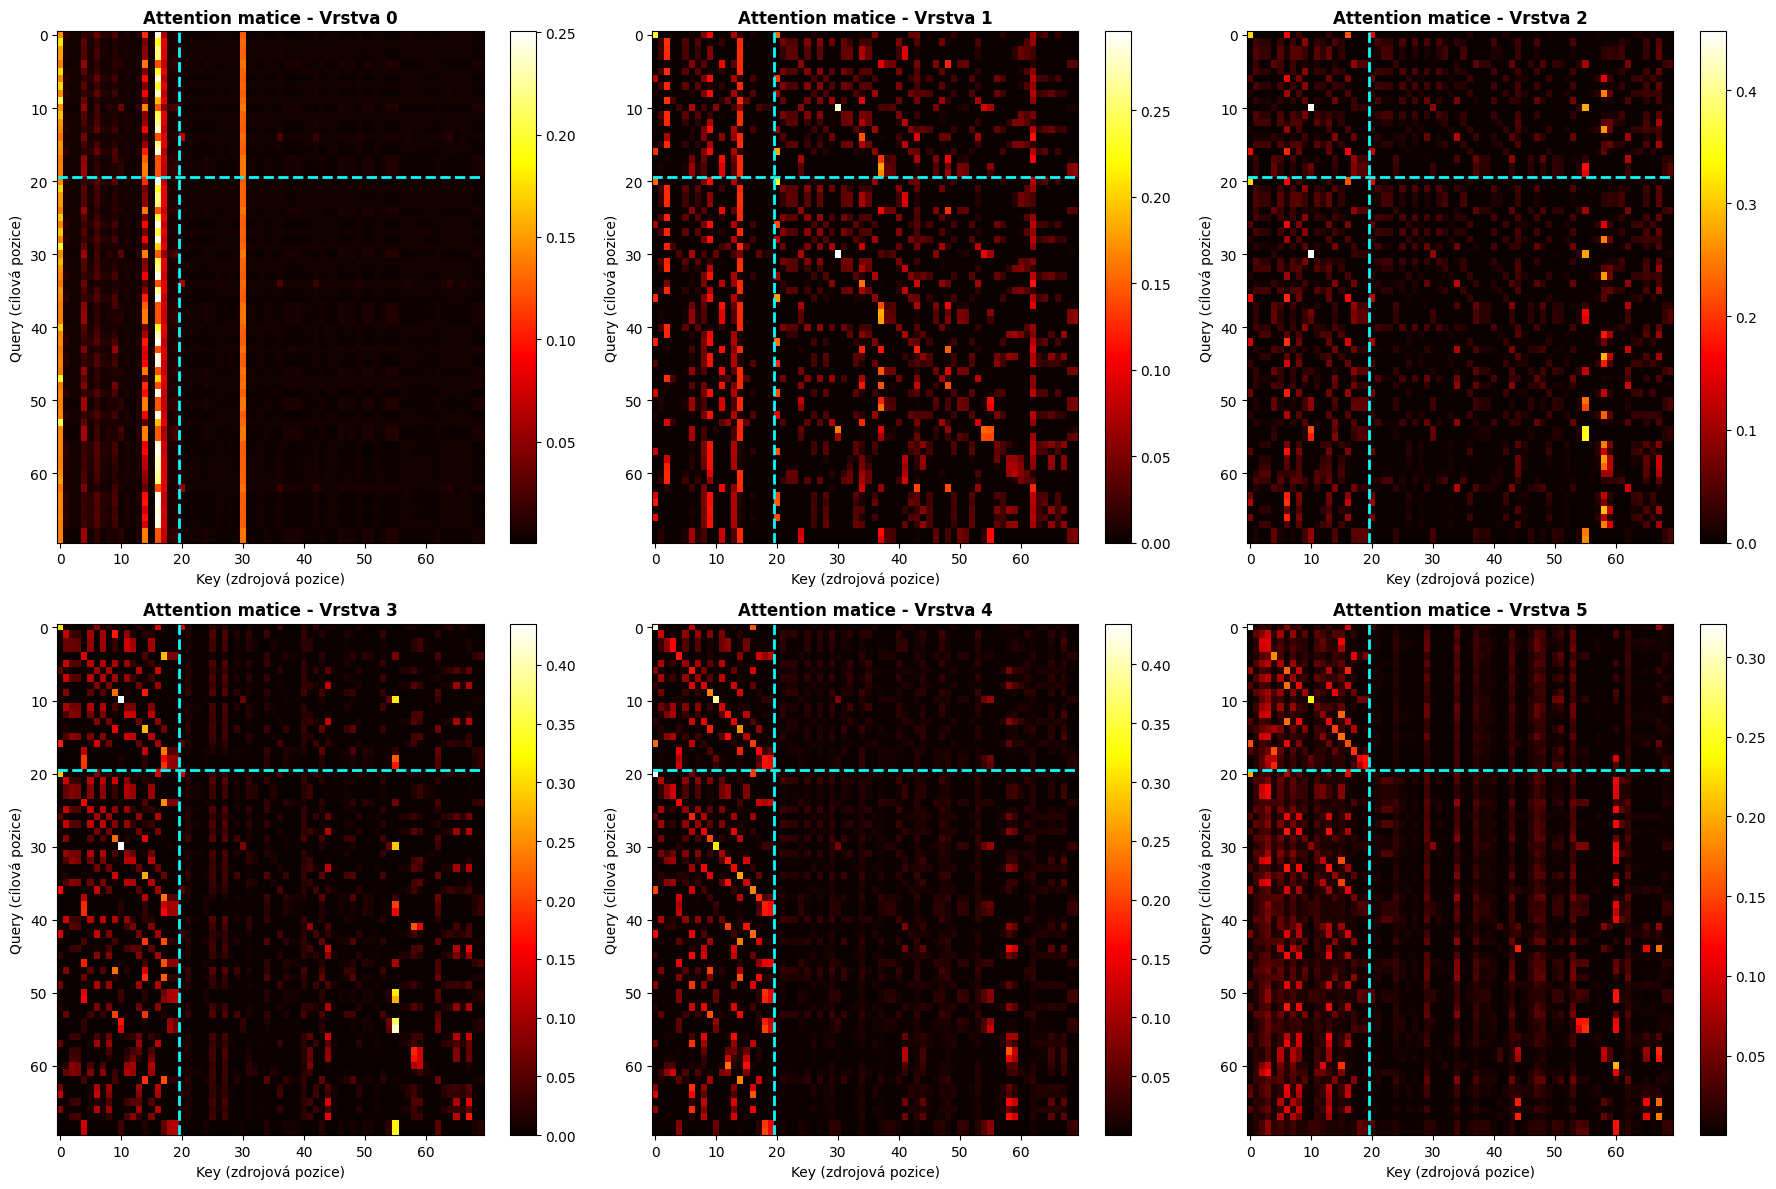

In [28]:
# =============================================
# EXPERIMENT 2: Zkoumání Attention vah
# =============================================
import torch.nn.functional as F

def compute_attention_weights(model, train_x, train_y, test_x):
    """
    Zachytí vstupy do attention a manuálně vypočítá attention váhy.
    """
    model.eval()

    layer_inputs = []

    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())

    # Hook na attention vrstvy
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)

    with torch.no_grad():
        _ = model(train_x[None], train_y[None], test_x[None])

    for hook in hooks:
        hook.remove()

    # Vypočítej attention váhy pro každou vrstvu
    all_attention_weights = []

    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break

        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()

        batch, features, seq_len, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]

        x_flat = x.reshape(-1, embed_dim)

        W_q = w_qkv[0]
        W_k = w_qkv[1]

        W_q_t = W_q.permute(2, 0, 1)
        W_k_t = W_k.permute(2, 0, 1)

        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)

        Q = Q.reshape(batch, features, seq_len, n_heads, head_dim)
        K = K.reshape(batch, features, seq_len, n_heads, head_dim)

        Q = Q.permute(0, 1, 3, 2, 4)
        K = K.permute(0, 1, 3, 2, 4)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        all_attention_weights.append(attn_weights)

    return all_attention_weights, layer_inputs

# Použije globální train_x, train_y, test_x z buňky DATASET
attn_weights, layer_inputs = compute_attention_weights(loaded_model, train_x, train_y, test_x)

print(f"Počet vrstev: {len(attn_weights)}")
for i, w in enumerate(attn_weights):
    print(f"Vrstva {i}: attention shape = {w.shape}")



fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()

for layer_idx in range(6):
    # Průměr přes všechny heads
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()  # [seq_len, seq_len]

    ax = axes1[layer_idx]
    im = ax.imshow(attn_layer, cmap='hot', aspect='auto')
    ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.set_xlabel('Key (zdrojová pozice)')
    ax.set_ylabel('Query (cílová pozice)')
    ax.set_title(f'Attention matice - Vrstva {layer_idx}', fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Interpretace

  * Zde můžeme pozorovat, že pro větší model je struktura Attention matic více méně stejná.

  * Jediným zlepšením může být, že patterny v poslední matici jsou mnohem čistší než pro malý model, což opět dává dobrý smysl: delší trénink -> přesnější prokladání křikvkou.


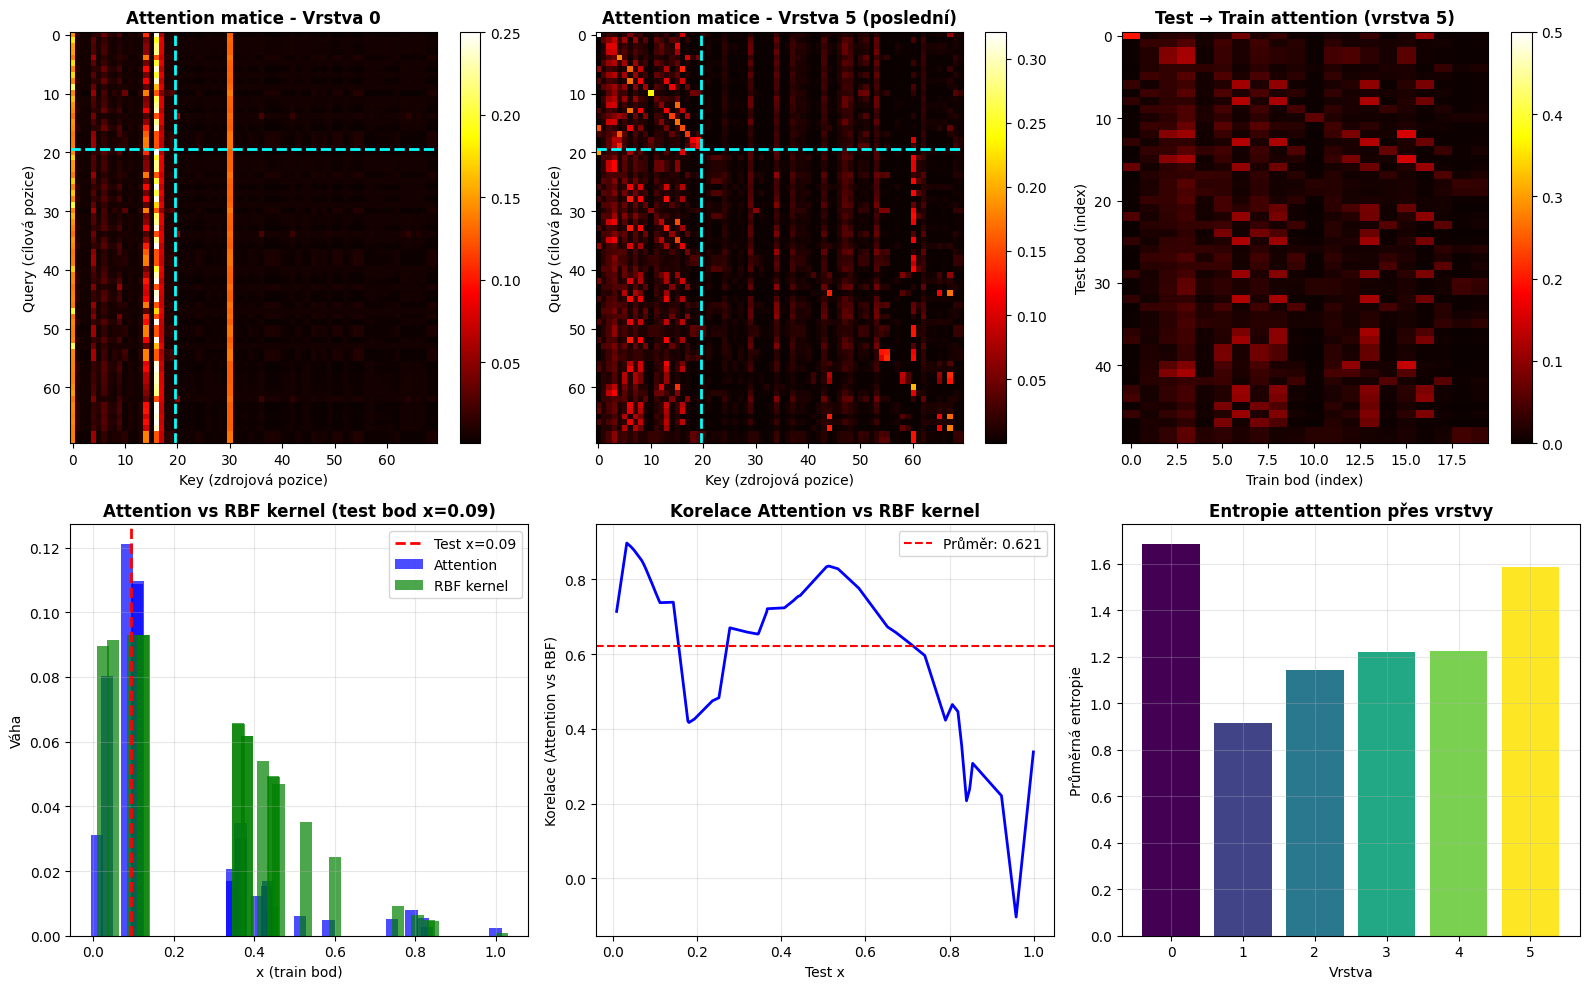


Průměrná korelace Attention vs RBF: 0.6210
Vyšší korelace = PFN se naučil kernel-like chování


In [29]:
# Průměr přes všechny heads
attn_layer0 = attn_weights[0][0, 0].mean(dim=0).detach().numpy()  # [70, 70]
attn_layer5 = attn_weights[5][0, 0].mean(dim=0).detach().numpy()  # [70, 70]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Attention matice - vrstva 0
ax = axes[0, 0]
im = ax.imshow(attn_layer0, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 0', fontweight='bold')
plt.colorbar(im, ax=ax)

# 2. Attention matice - vrstva 5 (poslední)
ax = axes[0, 1]
im = ax.imshow(attn_layer5, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 5 (poslední)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 3. Jak test body attendují na train body (vrstva 5)
# Test body jsou indexy n_context:70, train body jsou 0:n_context
test_to_train_attn = attn_layer5[n_context:, :n_context]  # [50, 20]

ax = axes[0, 2]
# DŮLEŽITÉ: použij STEJNÝ rozsah jako vlevo (vmin, vmax)
im = ax.imshow(test_to_train_attn, cmap='hot', aspect='auto',
               vmin=0, vmax=0.5)  # ← PŘIDÁNO
#              ^^^^^^^^^^^^^^
ax.set_xlabel('Train bod (index)')
ax.set_ylabel('Test bod (index)')
ax.set_title('Test → Train attention (vrstva 5)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 4. Attention vs RBF kernel pro jeden test bod
test_idx = 25  # Nějaký test bod (index v test sekvenci)
test_x_val = test_x[test_idx, 0].cpu().item()

# Attention váhy tohoto test bodu na train body
attn_to_train = attn_layer5[n_context + test_idx, :n_context]

# RBF kernel váhy
train_x_np = train_x[:, 0].cpu().numpy()
rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
rbf_weights_norm = rbf_weights / rbf_weights.sum()

# Seřaď podle x
order = np.argsort(train_x_np)

ax = axes[1, 0]
ax.bar(train_x_np[order], attn_to_train[order], width=0.03, alpha=0.7, label='Attention', color='blue')
ax.bar(train_x_np[order] + 0.015, rbf_weights_norm[order], width=0.03, alpha=0.7, label='RBF kernel', color='green')
ax.axvline(x=test_x_val, color='red', linestyle='--', lw=2, label=f'Test x={test_x_val:.2f}')
ax.set_xlabel('x (train bod)')
ax.set_ylabel('Váha')
ax.set_title(f'Attention vs RBF kernel (test bod x={test_x_val:.2f})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Korelace attention vs RBF pro všechny test body
correlations = []
for i in range(len(test_x)):
    test_x_val = test_x[i, 0].cpu().item()
    attn_to_train = attn_layer5[n_context + i, :n_context]

    rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
    rbf_weights_norm = rbf_weights / rbf_weights.sum()

    corr = np.corrcoef(attn_to_train, rbf_weights_norm)[0, 1]
    correlations.append(corr)

ax = axes[1, 1]
test_x_sorted_idx = test_x[:, 0].cpu().argsort()
ax.plot(test_x[test_x_sorted_idx, 0].cpu().numpy(), np.array(correlations)[test_x_sorted_idx], 'b-', lw=2)
ax.set_xlabel('Test x')
ax.set_ylabel('Korelace (Attention vs RBF)')
ax.set_title('Korelace Attention vs RBF kernel', fontweight='bold')
ax.axhline(y=np.mean(correlations), color='red', linestyle='--', label=f'Průměr: {np.mean(correlations):.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Vývoj attention přes vrstvy
ax = axes[1, 2]
for layer_idx in range(6):
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()
    test_to_train = attn_layer[n_context:, :n_context]

    # Průměrná "ostrost" attention (entropie)
    entropy = -np.sum(test_to_train * np.log(test_to_train + 1e-10), axis=1).mean()
    ax.bar(layer_idx, entropy, color=plt.cm.viridis(layer_idx/5))

ax.set_xlabel('Vrstva')
ax.set_ylabel('Průměrná entropie')
ax.set_title('Entropie attention přes vrstvy', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrůměrná korelace Attention vs RBF: {np.mean(correlations):.4f}")
print(f"Vyšší korelace = PFN se naučil kernel-like chování")

# Interpreace

*  Levý graf — attention a RBF  mají podobný celkový trend (obě rostou směrem k test bodu x=0.94), ale attention je výrazně ostřejší. Dává skoro veškerou váhu nejbližšímu bodu, zatímco RBF distribuuje váhu plynuleji.
To dává smysl. RBF kernel je optimální pro výpočet kernel similarity k(x^*, X), ale attention hlavy nemusí počítat čistou kernel similarity. Ony počítají to, co v kombinaci s ostatními hlavami a FFN vrstvami dává nejlepší GP posterior. A pro ten může být výhodnější ostřejší kernel — třeba proto, že FFN pak snadno provede korekci na K−1K^{-1}.

* Opět máme potvrzení, že PFN se nenaučil RBF kernel, ale naučil se vlastní implicitní kernel, který je optimalizovaný pro to, aby celý transformer dal správný GP posterior. A tohle platí konzistentně pro malý i velký model.


n_context= 5: MSE PFN=0.0984±0.2832  MSE GP=0.1534±0.5382
n_context=10: MSE PFN=0.0039±0.0038  MSE GP=0.0024±0.0015
n_context=15: MSE PFN=0.0022±0.0014  MSE GP=0.0023±0.0023
n_context=20: MSE PFN=0.0018±0.0005  MSE GP=0.0015±0.0003


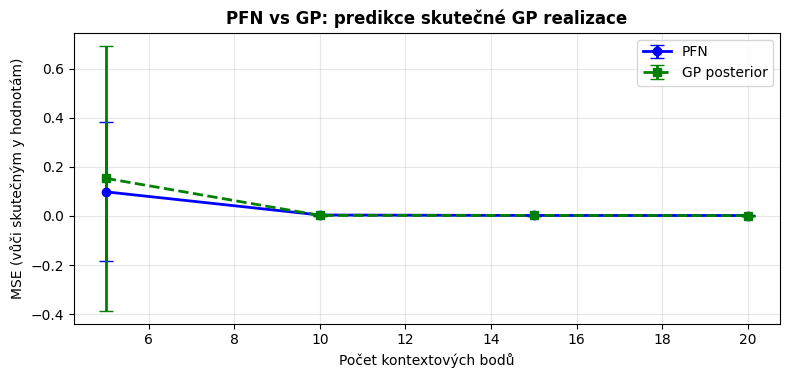

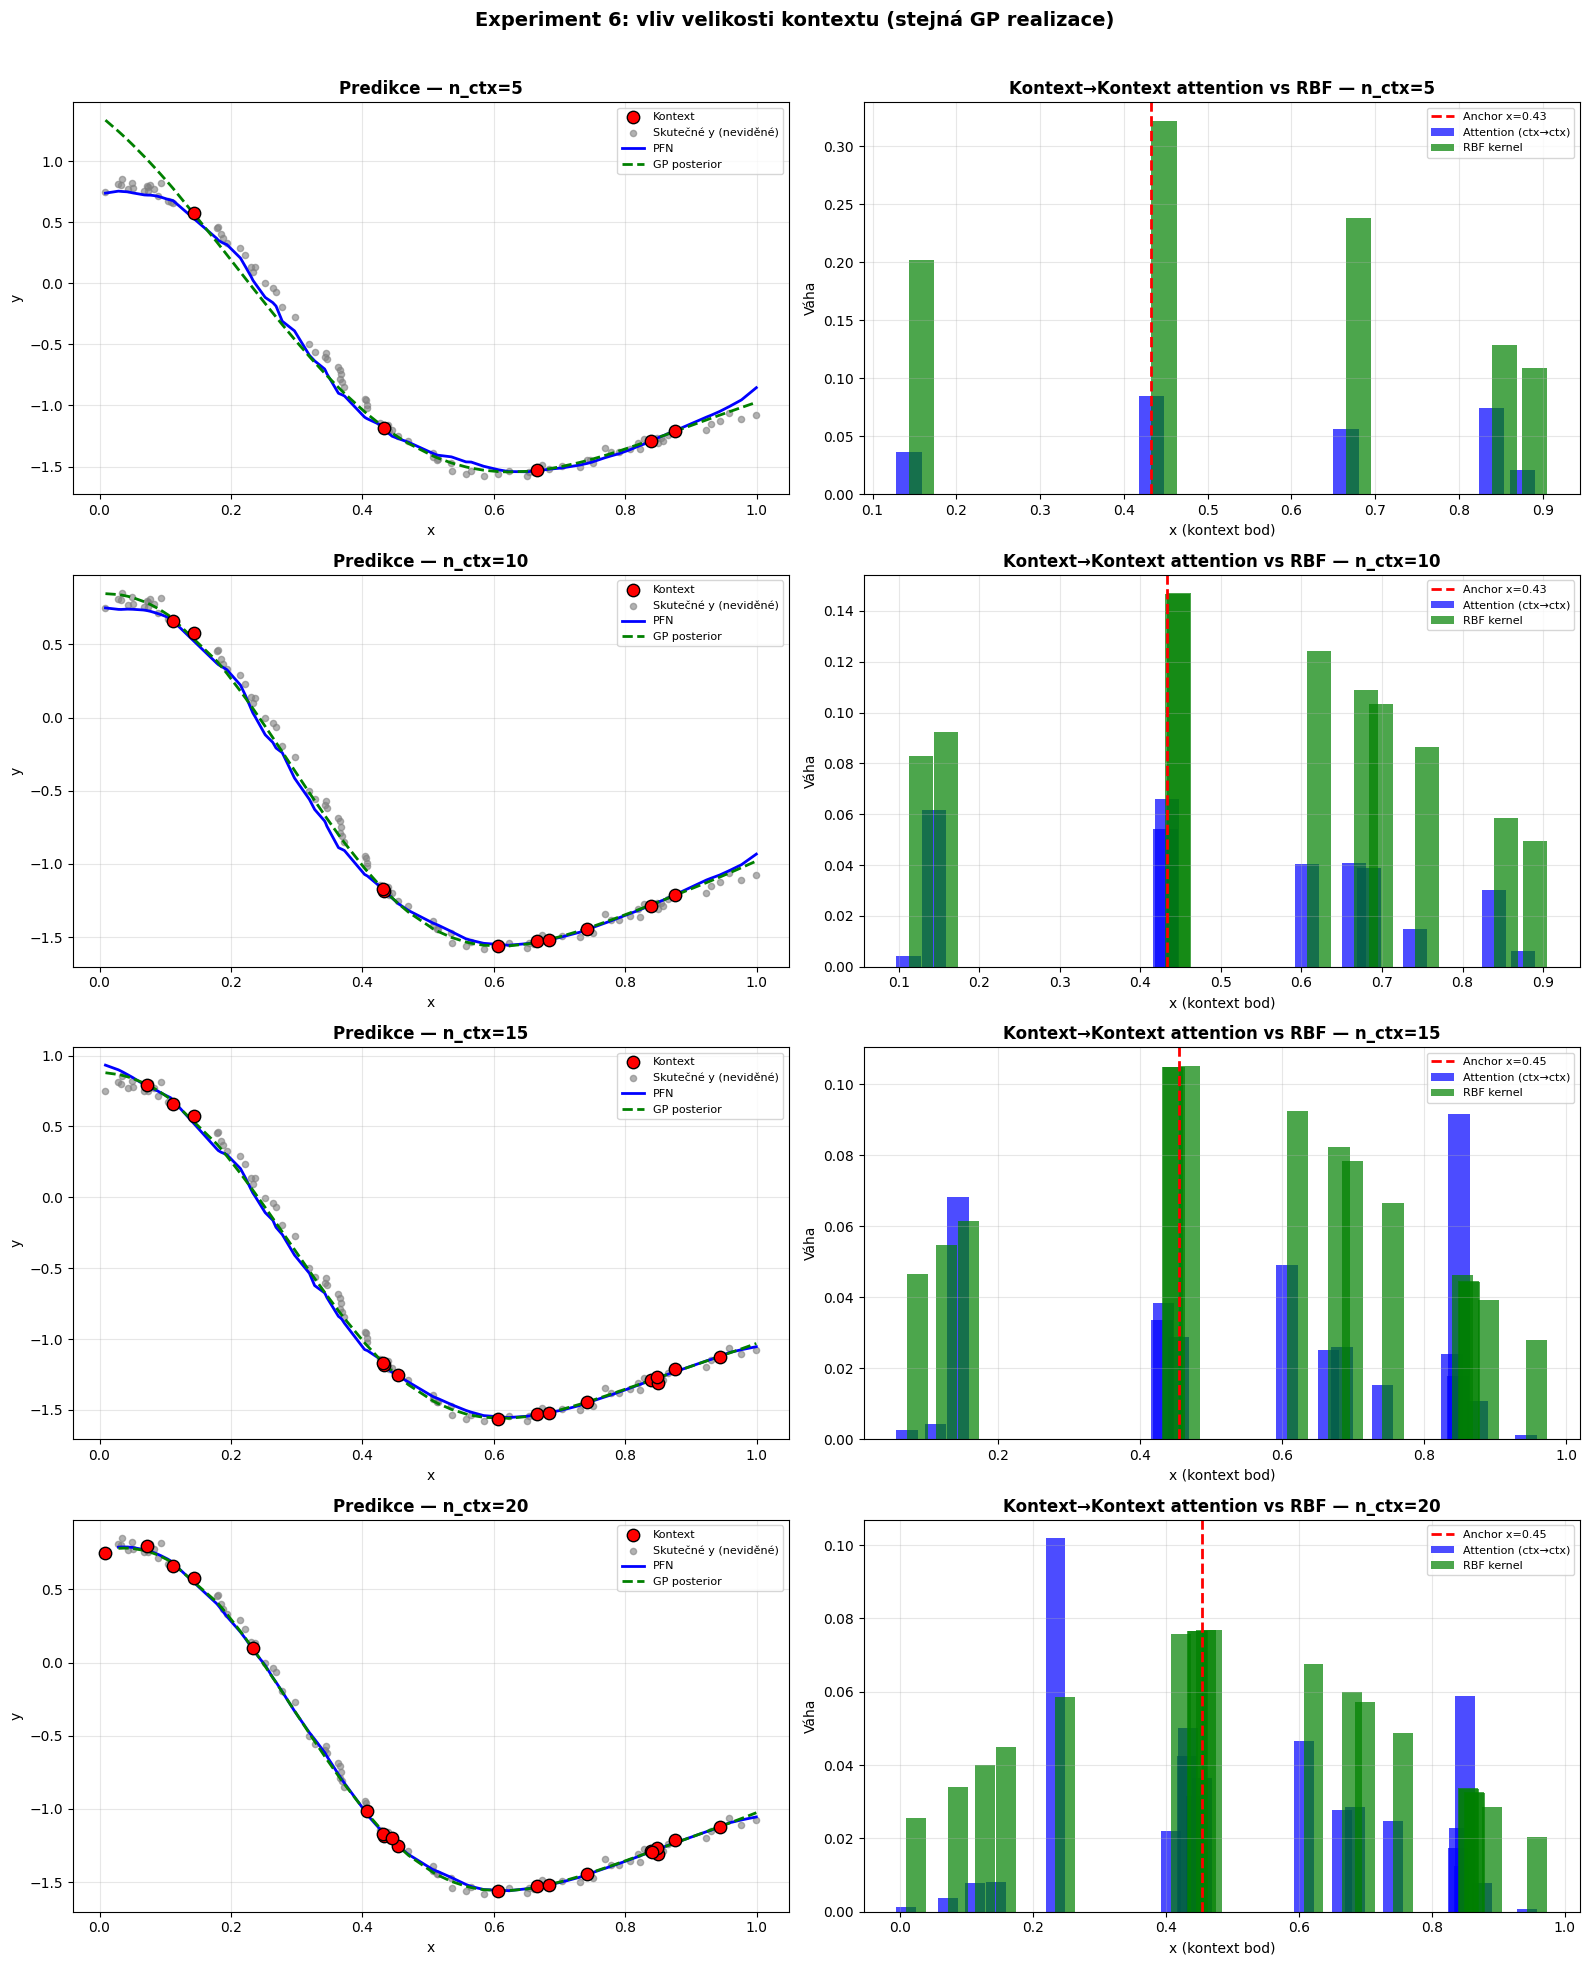

In [33]:
# =============================================
# EXPERIMENT 3: PFN inference na reálné GP realizaci
# =============================================
# PFN dostane pouze část skutečně naměřených bodů
# a musí odhadnout zbývající skutečné hodnoty.
# Ground truth = skutečné nasamplované y hodnoty (ne GP posteriorní mean).

N_CONTEXT_LIST = [5, 10, 15, 20]
N_TOTAL        = 100
TEST_IDX_ATTN  = 25   # index test bodu pro histogram attention vs RBF

def experiment_partial_observation(model, hps, n_total=N_TOTAL, n_context_list=N_CONTEXT_LIST):
    results = []
    for n_ctx in n_context_list:
        mses_pfn, mses_gp = [], []
        for _ in range(20):
            batch  = get_batch_for_gp(batch_size=1, seq_len=n_total, num_features=1, hyperparameters=hps)
            all_x  = batch.x[0]; all_y = batch.y[0]
            idx    = torch.randperm(n_total)
            train_x = all_x[idx[:n_ctx]];  train_y = all_y[idx[:n_ctx]]
            test_x  = all_x[idx[n_ctx:]];  true_y  = all_y[idx[n_ctx:]]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
            gp     = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred = gp.predict(test_x.cpu().numpy())

            true_y_np = true_y.cpu().numpy()
            mses_pfn.append(np.mean((pfn_pred - true_y_np)**2))
            mses_gp.append (np.mean((gp_pred  - true_y_np)**2))

        results.append({
            'n_context':    n_ctx,
            'mse_pfn_mean': np.mean(mses_pfn), 'mse_pfn_std': np.std(mses_pfn),
            'mse_gp_mean':  np.mean(mses_gp),  'mse_gp_std':  np.std(mses_gp),
        })
        print(f"n_context={n_ctx:2d}: MSE PFN={np.mean(mses_pfn):.4f}±{np.std(mses_pfn):.4f}  "
              f"MSE GP={np.mean(mses_gp):.4f}±{np.std(mses_gp):.4f}")
    return results


results_partial = experiment_partial_observation(loaded_model, hps_demo)

# --- MSE summary ---
fig0, ax0 = plt.subplots(figsize=(8, 4))
n_ctx_vals = [r['n_context']    for r in results_partial]
ax0.errorbar(n_ctx_vals, [r['mse_pfn_mean'] for r in results_partial],
             yerr=[r['mse_pfn_std'] for r in results_partial],
             marker='o', capsize=5, lw=2, label='PFN', color='blue')
ax0.errorbar(n_ctx_vals, [r['mse_gp_mean']  for r in results_partial],
             yerr=[r['mse_gp_std']  for r in results_partial],
             marker='s', capsize=5, lw=2, label='GP posterior', color='green', linestyle='--')
ax0.set_xlabel('Počet kontextových bodů')
ax0.set_ylabel('MSE (vůči skutečným y hodnotám)')
ax0.set_title('PFN vs GP: predikce skutečné GP realizace', fontweight='bold')
ax0.legend(); ax0.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

# --- Jeden řádek grafů pro každý n_ctx ---
# Sdílená realizace GP pro všechny kontexty (stejná data, různě velký kontext)
batch_vis = get_batch_for_gp(batch_size=1, seq_len=N_TOTAL, num_features=1, hyperparameters=hps_demo)
all_x_vis = batch_vis.x[0]; all_y_vis = batch_vis.y[0]
perm      = torch.randperm(N_TOTAL)   # stejná permutace pro všechny n_ctx

fig, axes = plt.subplots(len(N_CONTEXT_LIST), 2, figsize=(16, 5 * len(N_CONTEXT_LIST)))

for row, n_ctx in enumerate(N_CONTEXT_LIST):
    ctx_idx  = perm[:n_ctx];  test_idx_vis = perm[n_ctx:]
    train_x  = all_x_vis[ctx_idx];   train_y  = all_y_vis[ctx_idx]
    test_x   = all_x_vis[test_idx_vis]; true_y = all_y_vis[test_idx_vis]

    # PFN predikce
    with torch.no_grad():
        logits = loaded_model(train_x[None], train_y[None], test_x[None])
    pfn_pred = loaded_model.criterion.mean(logits)[0].cpu().numpy()

    # GP predikce
    kernel = ConstantKernel(hps_demo['outputscale']) * RBF(length_scale=hps_demo['lengthscale'])
    gp     = GaussianProcessRegressor(kernel=kernel, alpha=hps_demo['noise'])
    gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
    gp_pred = gp.predict(test_x.cpu().numpy())

    t_order = test_x[:, 0].cpu().argsort()

    # ── levý sloupec: predikce ──
    ax_pred = axes[row, 0]
    ax_pred.scatter(train_x[:, 0].cpu(), train_y.cpu(),
                    c='red', s=80, zorder=10, label='Kontext', edgecolors='black')
    ax_pred.scatter(test_x[t_order, 0].cpu(), true_y.cpu()[t_order],
                    c='gray', s=20, alpha=0.6, label='Skutečné y (neviděné)')
    ax_pred.plot(test_x[t_order, 0].cpu(), pfn_pred[t_order], 'b-',  lw=2, label='PFN')
    ax_pred.plot(test_x[t_order, 0].cpu(), gp_pred[t_order],  'g--', lw=2, label='GP posterior')
    ax_pred.set_title(f'Predikce — n_ctx={n_ctx}', fontweight='bold')
    ax_pred.set_xlabel('x'); ax_pred.set_ylabel('y')
    ax_pred.legend(fontsize=8); ax_pred.grid(True, alpha=0.3)

    # ── pravý sloupec: attention kontext→kontext vs RBF ──
    all_seq_x = torch.cat([train_x, test_x], dim=0)
    attn_w, _ = compute_attention_weights(loaded_model, train_x, train_y, all_seq_x)
    attn_layer5 = attn_w[5][0, 0].mean(dim=0).detach().numpy()

    train_x_np  = train_x[:, 0].cpu().numpy()
    order       = np.argsort(train_x_np)
    # Vyber kontext bod nejblíže x=0.5
    ctx_pick    = int(np.argmin(np.abs(train_x_np - 0.5)))
    anchor_x    = train_x_np[ctx_pick]

    # Attention tohoto kontext bodu na VŠECHNY ostatní kontext body
    attn_ctx2ctx = attn_layer5[ctx_pick, :n_ctx]   # řádek ctx_pick, sloupce 0..n_ctx

    # RBF kernel: k(anchor, x_j) normalizovaný
    rbf_raw  = np.exp(-0.5 * (train_x_np - anchor_x)**2 / hps_demo['lengthscale']**2)
    rbf_norm = rbf_raw / rbf_raw.sum()

    ax_attn = axes[row, 1]
    ax_attn.bar(train_x_np[order],         attn_ctx2ctx[order], width=0.03,
                alpha=0.7, label='Attention (ctx→ctx)', color='blue')
    ax_attn.bar(train_x_np[order] + 0.015, rbf_norm[order],     width=0.03,
                alpha=0.7, label='RBF kernel', color='green')
    ax_attn.axvline(x=anchor_x, color='red', linestyle='--', lw=2,
                    label=f'Anchor x={anchor_x:.2f}')
    ax_attn.set_title(f'Kontext→Kontext attention vs RBF — n_ctx={n_ctx}', fontweight='bold')
    ax_attn.set_xlabel('x (kontext bod)'); ax_attn.set_ylabel('Váha')
    ax_attn.legend(fontsize=8); ax_attn.grid(True, alpha=0.3)

plt.suptitle('Experiment 6: vliv velikosti kontextu (stejná GP realizace)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
# NOVÉ EXPERIMENTY PRO MODEL S DISTRIBUCÍ HP
# Experimenty 7–12: testují schopnost modelu identifikovat hyperparametry z dat
---

EXPERIMENT 7: Rozpozná model správný lengthscale?
LS=0.05: MSE(PFN, GP_correct)=0.099605, MSE(PFN, GP_wrong)=0.099605
LS=0.10: MSE(PFN, GP_correct)=0.009963, MSE(PFN, GP_wrong)=0.009963
LS=0.30: MSE(PFN, GP_correct)=0.000339, MSE(PFN, GP_wrong)=0.000339
LS=0.50: MSE(PFN, GP_correct)=0.000034, MSE(PFN, GP_wrong)=0.000034
LS=0.80: MSE(PFN, GP_correct)=0.000007, MSE(PFN, GP_wrong)=0.000007


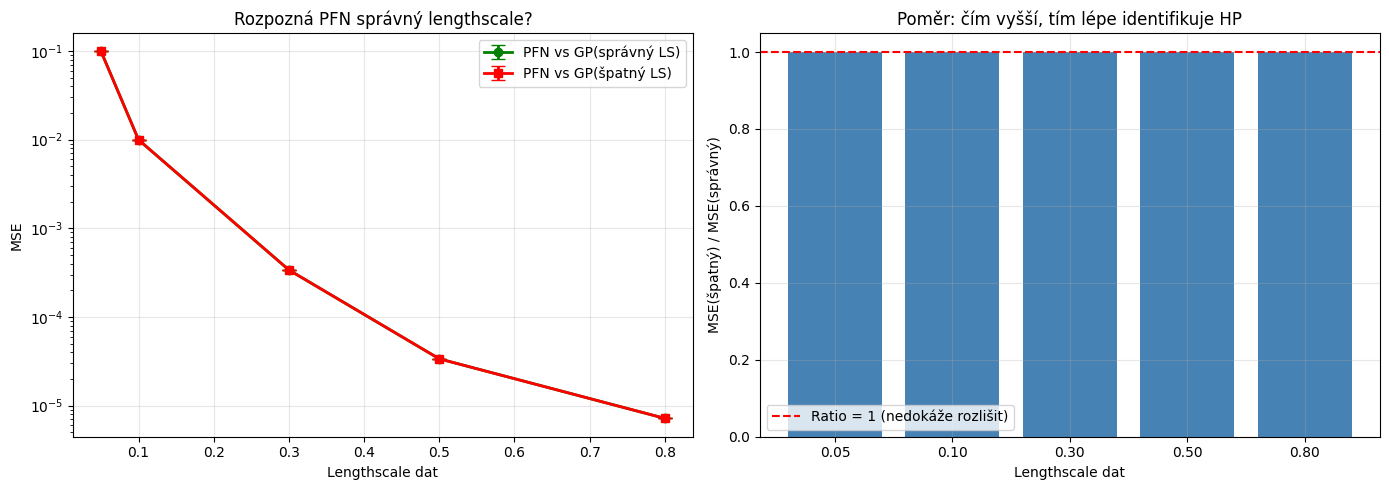

In [34]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# =============================================
# EXPERIMENT 4: Rozpozná model správný lengthscale?
# =============================================
# Hypotéza: PFN trénovaný na distribuci HP identifikuje
# správné HP z dat — jeho predikce bude bližší GP(správný LS)
# než GP(špatný LS).

def test_hp_recognition(model, test_lengthscales=[0.05, 0.1, 0.3, 0.5, 0.8],
                        n_context=20, seq_len=100, n_trials=10):
    results = []

    for ls in test_lengthscales:
        hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": ls}
        mse_pfn_correct = []
        mse_pfn_wrong = []

        for trial in range(n_trials):
            batch = get_batch_for_gp(
                batch_size=1, seq_len=seq_len, num_features=1,
                hyperparameters=hps_test
            )
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel_correct = ConstantKernel(1.0) * RBF(length_scale=ls)
            gp_correct = GaussianProcessRegressor(kernel=kernel_correct, alpha=1e-4)
            gp_correct.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_correct = gp_correct.predict(test_x.cpu().numpy())

            wrong_ls = 0.3 if ls != 0.3 else 0.1
            kernel_wrong = ConstantKernel(1.0) * RBF(length_scale=wrong_ls)
            gp_wrong = GaussianProcessRegressor(kernel=kernel_wrong, alpha=1e-4)
            gp_wrong.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_wrong = gp_wrong.predict(test_x.cpu().numpy())

            mse_pfn_correct.append(np.mean((pfn_pred - gp_pred_correct)**2))
            mse_pfn_wrong.append(np.mean((pfn_pred - gp_pred_wrong)**2))

        results.append({
            'lengthscale': ls,
            'mse_correct_mean': np.mean(mse_pfn_correct),
            'mse_correct_std': np.std(mse_pfn_correct),
            'mse_wrong_mean': np.mean(mse_pfn_wrong),
            'mse_wrong_std': np.std(mse_pfn_wrong),
        })
        print(f"LS={ls:.2f}: MSE(PFN, GP_correct)={np.mean(mse_pfn_correct):.6f}, "
              f"MSE(PFN, GP_wrong)={np.mean(mse_pfn_wrong):.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ls_vals = [r['lengthscale'] for r in results]

    ax = axes[0]
    ax.errorbar(ls_vals, [r['mse_correct_mean'] for r in results],
                yerr=[r['mse_correct_std'] for r in results],
                marker='o', lw=2, capsize=5, label='PFN vs GP(správný LS)', color='green')
    ax.errorbar(ls_vals, [r['mse_wrong_mean'] for r in results],
                yerr=[r['mse_wrong_std'] for r in results],
                marker='s', lw=2, capsize=5, label='PFN vs GP(špatný LS)', color='red')
    ax.set_xlabel('Lengthscale dat')
    ax.set_ylabel('MSE')
    ax.set_title('Rozpozná PFN správný lengthscale?')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    ratios = [r['mse_wrong_mean'] / max(r['mse_correct_mean'], 1e-10) for r in results]
    ax.bar(range(len(ls_vals)), ratios, tick_label=[f'{ls:.2f}' for ls in ls_vals], color='steelblue')
    ax.axhline(y=1, color='red', linestyle='--', label='Ratio = 1 (nedokáže rozlišit)')
    ax.set_xlabel('Lengthscale dat')
    ax.set_ylabel('MSE(špatný) / MSE(správný)')
    ax.set_title('Poměr: čím vyšší, tím lépe identifikuje HP')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return results


print("=" * 60)
print("EXPERIMENT 4: Rozpozná model správný lengthscale?")
print("=" * 60)
results_7 = test_hp_recognition(loaded_model)

# Interpretace Experimentu 7

* Pokud zelená křivka je výrazně pod červenou, PFN úspěšně identifikuje správný lengthscale z dat.
* Poměr v pravém grafu: hodnota >> 1 znamená, že PFN je mnohem blíž ke správnému GP.

EXPERIMENT 8: Kolik context bodů potřebuje na identifikaci HP?

--- Test s krátkým lengthscale (0.1) ---
n_ctx=  3: MSE(correct)=0.415448, MSE(wrong)=0.797478
n_ctx=  5: MSE(correct)=0.104859, MSE(wrong)=0.391808
n_ctx= 10: MSE(correct)=0.016549, MSE(wrong)=0.016549
n_ctx= 20: MSE(correct)=0.009963, MSE(wrong)=0.009963
n_ctx= 40: MSE(correct)=0.000093, MSE(wrong)=0.000093
n_ctx= 60: MSE(correct)=0.000056, MSE(wrong)=0.000056


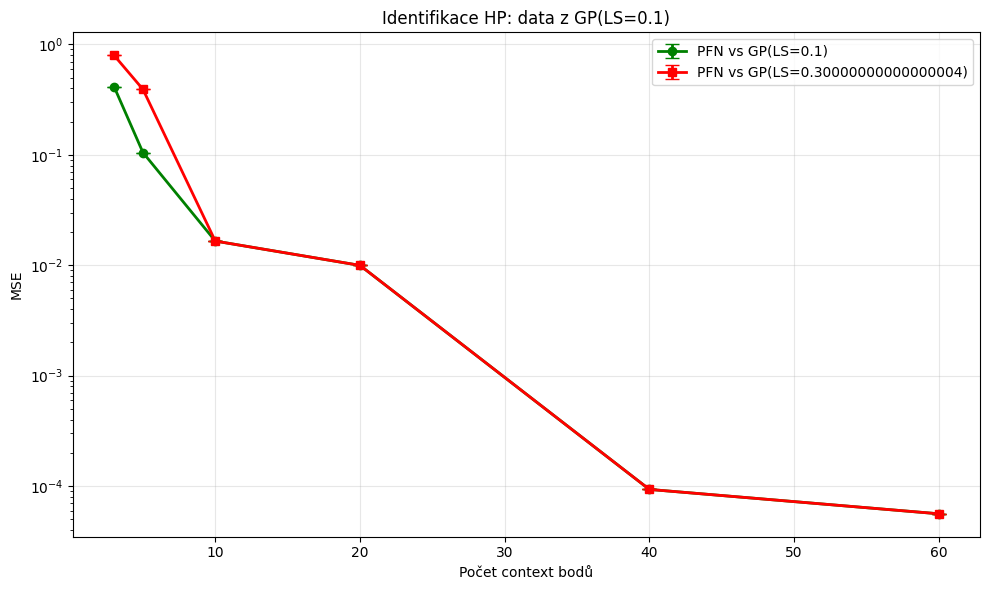


--- Test s dlouhým lengthscale (0.5) ---
n_ctx=  3: MSE(correct)=0.011439, MSE(wrong)=0.011440
n_ctx=  5: MSE(correct)=0.000314, MSE(wrong)=0.000314
n_ctx= 10: MSE(correct)=0.000269, MSE(wrong)=0.000269
n_ctx= 20: MSE(correct)=0.000034, MSE(wrong)=0.000034
n_ctx= 40: MSE(correct)=0.000002, MSE(wrong)=0.000002
n_ctx= 60: MSE(correct)=0.000001, MSE(wrong)=0.000001


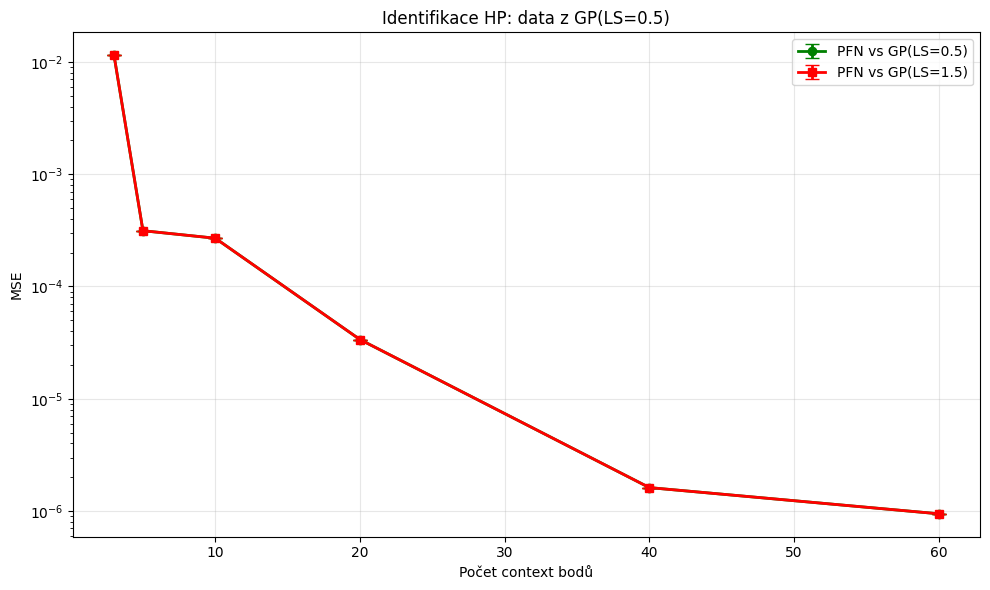

In [35]:
# =============================================
# EXPERIMENT 5: Kolik context bodů potřebuje na identifikaci HP?
# =============================================

def test_context_size_for_hp_identification(model, test_lengthscale=0.1,
                                             context_sizes=[3, 5, 10, 20, 40, 60],
                                             n_trials=15):
    hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": test_lengthscale}
    results = []

    for n_ctx in context_sizes:
        mse_correct_list = []
        mse_wrong_list = []

        for _ in range(n_trials):
            batch = get_batch_for_gp(
                batch_size=1, seq_len=max(100, n_ctx + 30), num_features=1,
                hyperparameters=hps_test
            )
            train_x = batch.x[0, :n_ctx]
            train_y = batch.y[0, :n_ctx]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel_c = ConstantKernel(1.0) * RBF(length_scale=test_lengthscale)
            gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-4)
            gp_c.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_c = gp_c.predict(test_x.cpu().numpy())

            kernel_w = ConstantKernel(1.0) * RBF(length_scale=test_lengthscale * 3)
            gp_w = GaussianProcessRegressor(kernel=kernel_w, alpha=1e-4)
            gp_w.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_w = gp_w.predict(test_x.cpu().numpy())

            mse_correct_list.append(np.mean((pfn_pred - gp_pred_c)**2))
            mse_wrong_list.append(np.mean((pfn_pred - gp_pred_w)**2))

        results.append({
            'n_context': n_ctx,
            'mse_correct': np.mean(mse_correct_list),
            'mse_correct_std': np.std(mse_correct_list),
            'mse_wrong': np.mean(mse_wrong_list),
            'mse_wrong_std': np.std(mse_wrong_list),
        })
        print(f"n_ctx={n_ctx:3d}: MSE(correct)={np.mean(mse_correct_list):.6f}, "
              f"MSE(wrong)={np.mean(mse_wrong_list):.6f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    n_vals = [r['n_context'] for r in results]
    ax.errorbar(n_vals, [r['mse_correct'] for r in results],
                yerr=[r['mse_correct_std'] for r in results],
                marker='o', lw=2, capsize=5, label=f'PFN vs GP(LS={test_lengthscale})', color='green')
    ax.errorbar(n_vals, [r['mse_wrong'] for r in results],
                yerr=[r['mse_wrong_std'] for r in results],
                marker='s', lw=2, capsize=5, label=f'PFN vs GP(LS={test_lengthscale*3})', color='red')
    ax.set_xlabel('Počet context bodů')
    ax.set_ylabel('MSE')
    ax.set_title(f'Identifikace HP: data z GP(LS={test_lengthscale})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
    return results


print("=" * 60)
print("EXPERIMENT 5: Kolik context bodů potřebuje na identifikaci HP?")
print("=" * 60)
print("\n--- Test s krátkým lengthscale (0.1) ---")
results_8a = test_context_size_for_hp_identification(loaded_model, test_lengthscale=0.1)
print("\n--- Test s dlouhým lengthscale (0.5) ---")
results_8b = test_context_size_for_hp_identification(loaded_model, test_lengthscale=0.5)

EXPERIMENT 9: PFN vs Type-II ML
HP: LS=0.1, noise=0.0001
  PFN:   MSE=0.009963, time=16.9ms
  ML-II: MSE=0.000071, time=31.4ms
  Speedup: 1.9x
HP: LS=0.3, noise=0.0001
  PFN:   MSE=0.000339, time=16.2ms
  ML-II: MSE=0.000000, time=27.3ms
  Speedup: 1.7x
HP: LS=0.7, noise=0.0001
  PFN:   MSE=0.000014, time=15.0ms
  ML-II: MSE=0.000000, time=23.7ms
  Speedup: 1.6x
HP: LS=0.3, noise=0.01
  PFN:   MSE=0.000718, time=19.6ms
  ML-II: MSE=0.000009, time=26.5ms
  Speedup: 1.4x


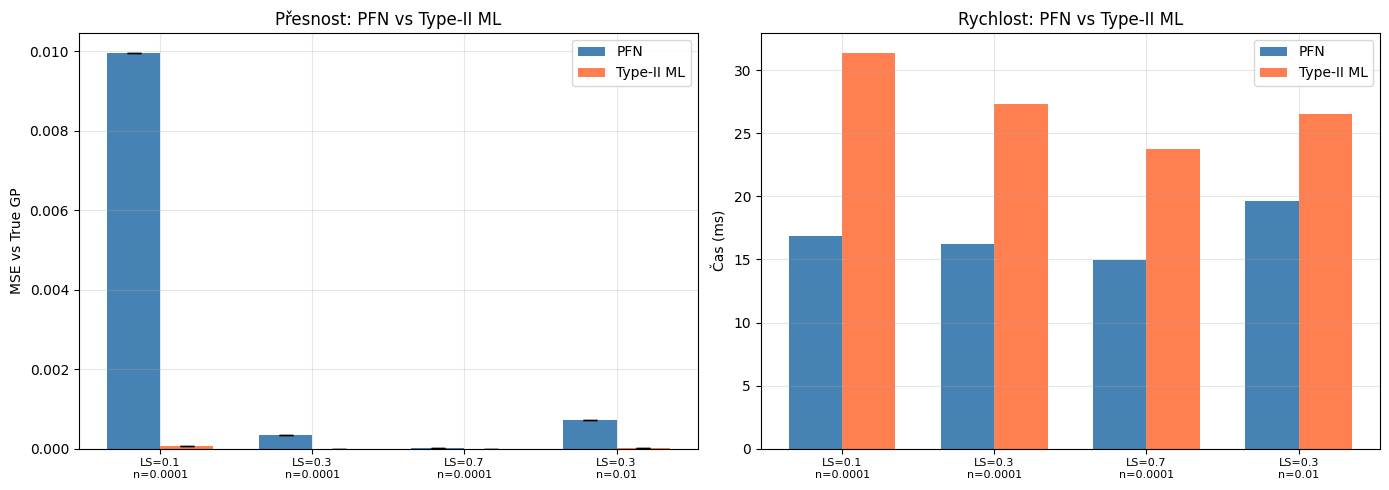

In [36]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# =============================================
# EXPERIMENT 6: PFN vs Type-II ML
# =============================================

def type2_ml_predict(train_x_np, train_y_np, test_x_np):
    kernel = ConstantKernel(1.0, (0.01, 10.0)) * RBF(0.3, (0.01, 5.0)) + WhiteKernel(1e-4, (1e-6, 1e-1))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
    gp.fit(train_x_np, train_y_np)
    mean, std = gp.predict(test_x_np, return_std=True)
    return mean, std, gp.kernel_


def test_pfn_vs_type2ml(model, test_hps_list=None, n_context=20, n_trials=10):
    if test_hps_list is None:
        test_hps_list = [
            {"noise": 1e-4, "outputscale": 1.0, "lengthscale": 0.1},
            {"noise": 1e-4, "outputscale": 1.0, "lengthscale": 0.3},
            {"noise": 1e-4, "outputscale": 1.0, "lengthscale": 0.7},
            {"noise": 1e-2, "outputscale": 0.5, "lengthscale": 0.3},
        ]

    all_results = []
    for hps_test in test_hps_list:
        ls = hps_test['lengthscale']
        mse_pfn_list, mse_ml2_list = [], []
        time_pfn_list, time_ml2_list = [], []

        for trial in range(n_trials):
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test)
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            kernel_true = ConstantKernel(hps_test['outputscale']) * RBF(length_scale=ls)
            gp_true = GaussianProcessRegressor(kernel=kernel_true, alpha=hps_test['noise'])
            gp_true.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_true = gp_true.predict(test_x.cpu().numpy())

            t0 = time.time()
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()
            time_pfn = time.time() - t0

            t0 = time.time()
            ml2_pred, ml2_std, fitted_kernel = type2_ml_predict(
                train_x.cpu().numpy(), train_y.cpu().numpy(), test_x.cpu().numpy())
            time_ml2 = time.time() - t0

            mse_pfn_list.append(np.mean((pfn_pred - gp_pred_true)**2))
            mse_ml2_list.append(np.mean((ml2_pred - gp_pred_true)**2))
            time_pfn_list.append(time_pfn)
            time_ml2_list.append(time_ml2)

        result = {
            'hps': hps_test,
            'mse_pfn': np.mean(mse_pfn_list), 'mse_pfn_std': np.std(mse_pfn_list),
            'mse_ml2': np.mean(mse_ml2_list), 'mse_ml2_std': np.std(mse_ml2_list),
            'time_pfn': np.mean(time_pfn_list), 'time_ml2': np.mean(time_ml2_list),
        }
        all_results.append(result)
        print(f"HP: LS={ls}, noise={hps_test['noise']}")
        print(f"  PFN:   MSE={result['mse_pfn']:.6f}, time={result['time_pfn']*1000:.1f}ms")
        print(f"  ML-II: MSE={result['mse_ml2']:.6f}, time={result['time_ml2']*1000:.1f}ms")
        print(f"  Speedup: {result['time_ml2']/max(result['time_pfn'], 1e-6):.1f}x")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels = [f"LS={r['hps']['lengthscale']}\nn={r['hps']['noise']}" for r in all_results]
    x_pos = np.arange(len(labels))
    width = 0.35

    ax = axes[0]
    ax.bar(x_pos - width/2, [r['mse_pfn'] for r in all_results], width,
           yerr=[r['mse_pfn_std'] for r in all_results], label='PFN', color='steelblue', capsize=5)
    ax.bar(x_pos + width/2, [r['mse_ml2'] for r in all_results], width,
           yerr=[r['mse_ml2_std'] for r in all_results], label='Type-II ML', color='coral', capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('MSE vs True GP')
    ax.set_title('Přesnost: PFN vs Type-II ML')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(x_pos - width/2, [r['time_pfn']*1000 for r in all_results], width, label='PFN', color='steelblue')
    ax.bar(x_pos + width/2, [r['time_ml2']*1000 for r in all_results], width, label='Type-II ML', color='coral')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Čas (ms)')
    ax.set_title('Rychlost: PFN vs Type-II ML')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return all_results


print("=" * 60)
print("EXPERIMENT 6: PFN vs Type-II ML")
print("=" * 60)
results_9 = test_pfn_vs_type2ml(loaded_model)

EXPERIMENT 10: Chování na hranici distribuce HP
[IN ] LS=0.100: MSE(mean)=0.009963, MSE(std)=0.027335
[IN ] LS=0.300: MSE(mean)=0.000339, MSE(std)=0.000566
[IN ] LS=0.700: MSE(mean)=0.000014, MSE(std)=0.000086
[OUT] LS=0.010: MSE(mean)=0.144321, MSE(std)=0.041190
[OUT] LS=0.030: MSE(mean)=0.264898, MSE(std)=0.057244
[OUT] LS=1.500: MSE(mean)=0.000007, MSE(std)=0.000127
[OUT] LS=2.000: MSE(mean)=0.000004, MSE(std)=0.000120
[OUT] LS=3.000: MSE(mean)=0.000005, MSE(std)=0.000153


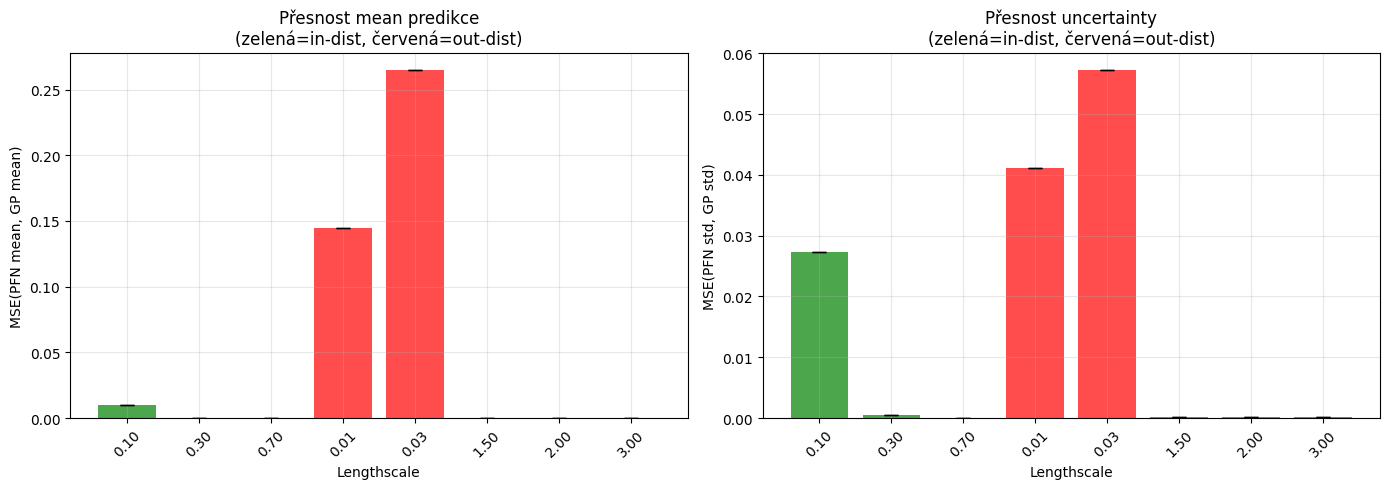

In [37]:
# =============================================
# EXPERIMENT 7: Chování na hranici distribuce HP
# =============================================
# Trénováno s LS ~ Uniform(0.05, 1.0).
# Co se stane pro LS mimo tento rozsah?

def test_hp_boundary(model, n_context=20, n_trials=10):
    in_dist = [0.1, 0.3, 0.7]
    out_dist = [0.01, 0.03, 1.5, 2.0, 3.0]
    all_ls = in_dist + out_dist
    results = []

    for ls in all_ls:
        hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": ls}
        mse_list, mse_unc_list = [], []

        for _ in range(n_trials):
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test)
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()
            pfn_std = np.sqrt(model.criterion.variance(logits)[0].cpu().numpy())

            kernel = ConstantKernel(1.0) * RBF(length_scale=ls)
            gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4)
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred, gp_std = gp.predict(test_x.cpu().numpy(), return_std=True)

            mse_list.append(np.mean((pfn_pred - gp_pred)**2))
            mse_unc_list.append(np.mean((pfn_std - gp_std)**2))

        is_in = ls in in_dist
        results.append({
            'lengthscale': ls, 'in_distribution': is_in,
            'mse_mean': np.mean(mse_list), 'mse_std': np.std(mse_list),
            'mse_unc_mean': np.mean(mse_unc_list), 'mse_unc_std': np.std(mse_unc_list),
        })
        tag = "IN " if is_in else "OUT"
        print(f"[{tag}] LS={ls:.3f}: MSE(mean)={np.mean(mse_list):.6f}, MSE(std)={np.mean(mse_unc_list):.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ls_vals = [r['lengthscale'] for r in results]
    colors = ['green' if r['in_distribution'] else 'red' for r in results]

    ax = axes[0]
    ax.bar(range(len(results)), [r['mse_mean'] for r in results],
           yerr=[r['mse_std'] for r in results], color=colors, capsize=5, alpha=0.7)
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels([f'{ls:.2f}' for ls in ls_vals], rotation=45)
    ax.set_xlabel('Lengthscale')
    ax.set_ylabel('MSE(PFN mean, GP mean)')
    ax.set_title('Přesnost mean predikce\n(zelená=in-dist, červená=out-dist)')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(range(len(results)), [r['mse_unc_mean'] for r in results],
           yerr=[r['mse_unc_std'] for r in results], color=colors, capsize=5, alpha=0.7)
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels([f'{ls:.2f}' for ls in ls_vals], rotation=45)
    ax.set_xlabel('Lengthscale')
    ax.set_ylabel('MSE(PFN std, GP std)')
    ax.set_title('Přesnost uncertainty\n(zelená=in-dist, červená=out-dist)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return results


print("=" * 60)
print("EXPERIMENT 7: Chování na hranici distribuce HP")
print("=" * 60)
results_10 = test_hp_boundary(loaded_model)

EXPERIMENT 10b: Jaký lengthscale PFN implicitně odhadl?
True LS=0.05 → Estimated LS=0.171 ± 0.000
True LS=0.10 → Estimated LS=0.715 ± 0.000
True LS=0.20 → Estimated LS=1.138 ± 0.000
True LS=0.30 → Estimated LS=1.319 ± 0.000
True LS=0.50 → Estimated LS=1.319 ± 0.000
True LS=0.70 → Estimated LS=1.228 ± 0.000
True LS=0.90 → Estimated LS=1.047 ± 0.000


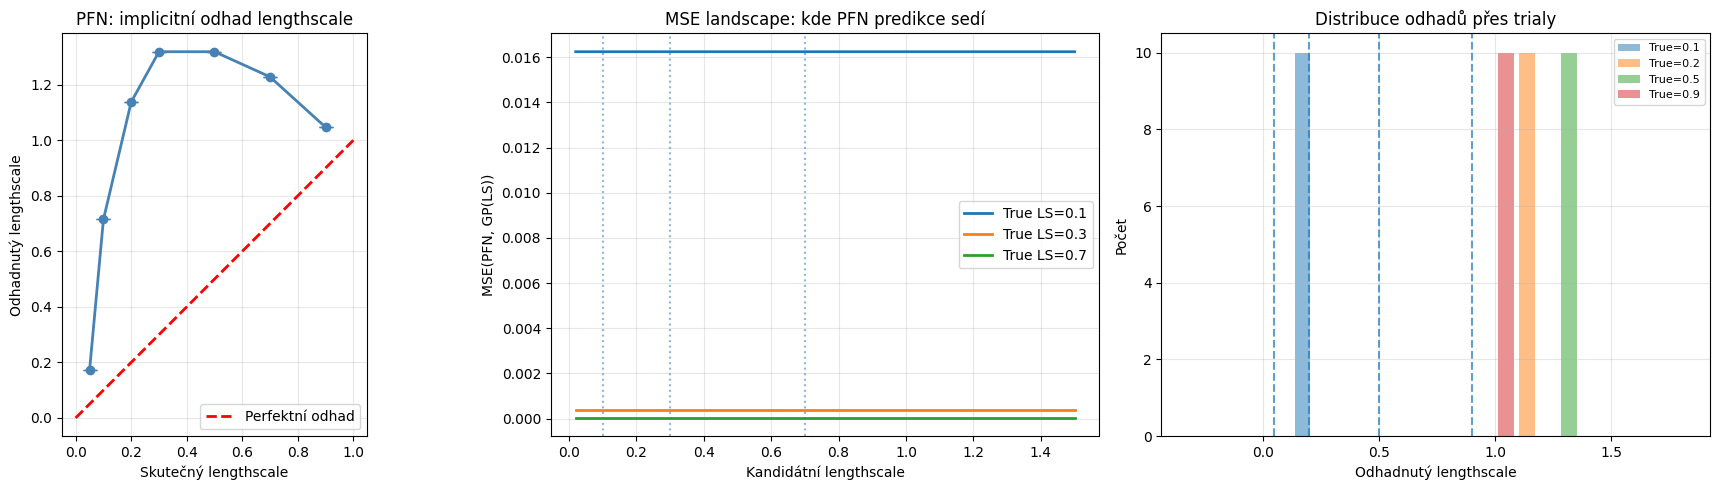

In [38]:
# =============================================
# EXPERIMENT 8: Jaký lengthscale PFN implicitně odhadl?
# =============================================
# Pro data z GP(LS_true) hledáme LS_estimated takové,
# že GP(LS_estimated) je nejblíž k PFN predikci.

def estimate_implicit_lengthscale(model, true_ls, n_context=20, seq_len=100,
                                   ls_grid=np.linspace(0.02, 1.5, 50)):
    hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": true_ls}
    batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1,
                              hyperparameters=hps_test)
    train_x = batch.x[0, :n_context]
    train_y = batch.y[0, :n_context]
    test_x = batch.x[0]

    # PFN predikce
    with torch.no_grad():
        logits = model(train_x[None], train_y[None], test_x[None])
    pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

    # Pro každý LS v gridu: spočítej GP predikci a MSE vůči PFN
    mse_per_ls = []
    for ls_candidate in ls_grid:
        kernel = ConstantKernel(1.0) * RBF(length_scale=ls_candidate)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3)
        gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_pred = gp.predict(test_x.cpu().numpy())
        mse_per_ls.append(np.mean((pfn_pred - gp_pred)**2))

    mse_per_ls = np.array(mse_per_ls)
    estimated_ls = ls_grid[np.argmin(mse_per_ls)]

    return estimated_ls, ls_grid, mse_per_ls, pfn_pred


def test_implicit_hp_estimation(model, true_lengthscales=[0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
                                 n_trials=10):
    results = []

    for true_ls in true_lengthscales:
        estimated_ls_list = []
        for _ in range(n_trials):
            est_ls, _, _, _ = estimate_implicit_lengthscale(model, true_ls)
            estimated_ls_list.append(est_ls)

        results.append({
            'true_ls': true_ls,
            'estimated_ls_mean': np.mean(estimated_ls_list),
            'estimated_ls_std': np.std(estimated_ls_list),
            'estimated_ls_all': estimated_ls_list,
        })
        print(f"True LS={true_ls:.2f} → Estimated LS={np.mean(estimated_ls_list):.3f} "
              f"± {np.std(estimated_ls_list):.3f}")

    # === Vizualizace 1: True vs Estimated LS ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    true_vals = [r['true_ls'] for r in results]
    est_vals = [r['estimated_ls_mean'] for r in results]
    est_stds = [r['estimated_ls_std'] for r in results]

    ax = axes[0]
    ax.errorbar(true_vals, est_vals, yerr=est_stds, marker='o', lw=2, capsize=5, color='steelblue')
    ax.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfektní odhad')
    ax.set_xlabel('Skutečný lengthscale')
    ax.set_ylabel('Odhadnutý lengthscale')
    ax.set_title('PFN: implicitní odhad lengthscale')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # === Vizualizace 2: MSE landscape pro jeden příklad ===
    ax = axes[1]
    for true_ls in [0.1, 0.3, 0.7]:
        _, ls_grid, mse_curve, _ = estimate_implicit_lengthscale(model, true_ls)
        ax.plot(ls_grid, mse_curve, lw=2, label=f'True LS={true_ls}')
        ax.axvline(x=true_ls, linestyle=':', alpha=0.5)
    ax.set_xlabel('Kandidátní lengthscale')
    ax.set_ylabel('MSE(PFN, GP(LS))')
    ax.set_title('MSE landscape: kde PFN predikce sedí')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # === Vizualizace 3: Histogram odhadů ===
    ax = axes[2]
    for r in results[::2]:  # každý druhý pro přehlednost
        ax.hist(r['estimated_ls_all'], bins=15, alpha=0.5,
                label=f'True={r["true_ls"]:.1f}')
        ax.axvline(x=r['true_ls'], linestyle='--', alpha=0.7)
    ax.set_xlabel('Odhadnutý lengthscale')
    ax.set_ylabel('Počet')
    ax.set_title('Distribuce odhadů přes trialy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results


print("=" * 60)
print("EXPERIMENT 8: Jaký lengthscale PFN implicitně odhadl?")
print("=" * 60)
results_10b = test_implicit_hp_estimation(loaded_model)

EXPERIMENT 10c: Odhadne PFN i outputscale a noise?
OS=0.1: MSE(correct)=0.000156, MSE(wrong)=0.000156
OS=0.3: MSE(correct)=0.000178, MSE(wrong)=0.000178
OS=0.5: MSE(correct)=0.000153, MSE(wrong)=0.000153
OS=1.0: MSE(correct)=0.000390, MSE(wrong)=0.000390
OS=2.0: MSE(correct)=0.000937, MSE(wrong)=0.000937
OS=5.0: MSE(correct)=0.375105, MSE(wrong)=0.375105

--- Noise rozpoznávání ---
Noise=1e-04: MSE(PFN, GP)=0.000339
Noise=1e-03: MSE(PFN, GP)=0.000390
Noise=1e-02: MSE(PFN, GP)=0.002133
Noise=1e-01: MSE(PFN, GP)=0.079884


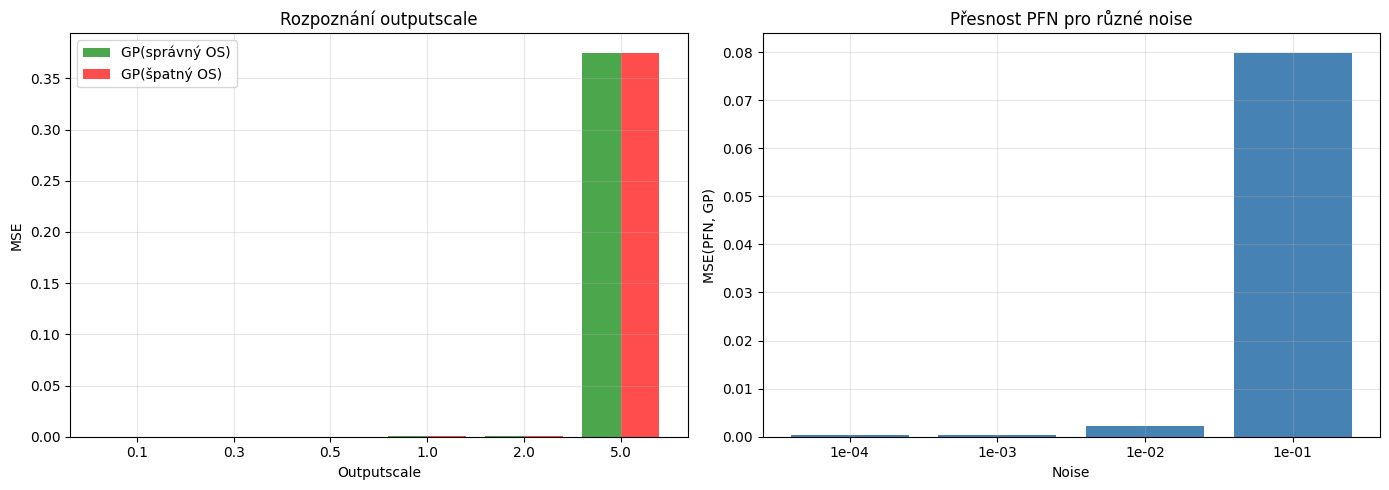

In [39]:
# =============================================
# EXPERIMENT 9: Odhadne PFN i outputscale a noise?
# =============================================
# Zafixujeme LS=0.3, měníme outputscale a noise.

def test_outputscale_recognition(model, outputscales=[0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
                                  n_context=20, n_trials=10):
    results = []

    for os_val in outputscales:
        hps_test = {"noise": 1e-3, "outputscale": os_val, "lengthscale": 0.3}
        mse_correct = []
        mse_wrong = []

        for _ in range(n_trials):
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1,
                                      hyperparameters=hps_test)
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            # GP správný outputscale
            kernel_c = ConstantKernel(os_val) * RBF(length_scale=0.3)
            gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-3)
            gp_c.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_c = gp_c.predict(test_x.cpu().numpy())

            # GP špatný outputscale (vždy 1.0)
            wrong_os = 1.0 if os_val != 1.0 else 0.3
            kernel_w = ConstantKernel(wrong_os) * RBF(length_scale=0.3)
            gp_w = GaussianProcessRegressor(kernel=kernel_w, alpha=1e-3)
            gp_w.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred_w = gp_w.predict(test_x.cpu().numpy())

            mse_correct.append(np.mean((pfn_pred - gp_pred_c)**2))
            mse_wrong.append(np.mean((pfn_pred - gp_pred_w)**2))

        results.append({
            'outputscale': os_val,
            'mse_correct': np.mean(mse_correct),
            'mse_wrong': np.mean(mse_wrong),
        })
        print(f"OS={os_val:.1f}: MSE(correct)={np.mean(mse_correct):.6f}, "
              f"MSE(wrong)={np.mean(mse_wrong):.6f}")

    # Noise rozpoznávání
    print("\n--- Noise rozpoznávání ---")
    noise_results = []
    for noise_val in [1e-4, 1e-3, 1e-2, 1e-1]:
        hps_test = {"noise": noise_val, "outputscale": 1.0, "lengthscale": 0.3}
        mse_list = []
        for _ in range(n_trials):
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1,
                                      hyperparameters=hps_test)
            train_x = batch.x[0, :n_context]
            train_y = batch.y[0, :n_context]
            test_x = batch.x[0]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel = ConstantKernel(1.0) * RBF(length_scale=0.3)
            gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_val)
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred = gp.predict(test_x.cpu().numpy())

            mse_list.append(np.mean((pfn_pred - gp_pred)**2))

        noise_results.append({'noise': noise_val, 'mse': np.mean(mse_list)})
        print(f"Noise={noise_val:.0e}: MSE(PFN, GP)={np.mean(mse_list):.6f}")

    # Vizualizace
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    os_vals = [r['outputscale'] for r in results]
    ax.bar(range(len(os_vals)),
           [r['mse_correct'] for r in results], width=0.4, label='GP(správný OS)', color='green', alpha=0.7)
    ax.bar([x+0.4 for x in range(len(os_vals))],
           [r['mse_wrong'] for r in results], width=0.4, label='GP(špatný OS)', color='red', alpha=0.7)
    ax.set_xticks([x+0.2 for x in range(len(os_vals))])
    ax.set_xticklabels([f'{v:.1f}' for v in os_vals])
    ax.set_xlabel('Outputscale')
    ax.set_ylabel('MSE')
    ax.set_title('Rozpoznání outputscale')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    noise_vals = [r['noise'] for r in noise_results]
    ax.bar(range(len(noise_vals)), [r['mse'] for r in noise_results], color='steelblue')
    ax.set_xticks(range(len(noise_vals)))
    ax.set_xticklabels([f'{v:.0e}' for v in noise_vals])
    ax.set_xlabel('Noise')
    ax.set_ylabel('MSE(PFN, GP)')
    ax.set_title('Přesnost PFN pro různé noise')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results, noise_results


print("=" * 60)
print("EXPERIMENT 9: Odhadne PFN i outputscale a noise?")
print("=" * 60)
results_10c_os, results_10c_noise = test_outputscale_recognition(loaded_model)

EXPERIMENT 10d: Ambiguita — marginalizace vs point estimate
n_ctx=  3: PFN=0.14439, ML-II=0.00392, Marginal=0.00000 | PFN~ML2=0.19476, PFN~Marg=0.14439
n_ctx=  5: PFN=0.00719, ML-II=1.03820, Marginal=0.13884 | PFN~ML2=0.90453, PFN~Marg=0.09343
n_ctx= 10: PFN=0.00323, ML-II=0.90942, Marginal=0.00000 | PFN~ML2=0.86786, PFN~Marg=0.00323
n_ctx= 20: PFN=0.00039, ML-II=0.60739, Marginal=0.00000 | PFN~ML2=0.60506, PFN~Marg=0.00039
n_ctx= 50: PFN=0.00001, ML-II=2.09040, Marginal=0.00000 | PFN~ML2=2.08881, PFN~Marg=0.00001


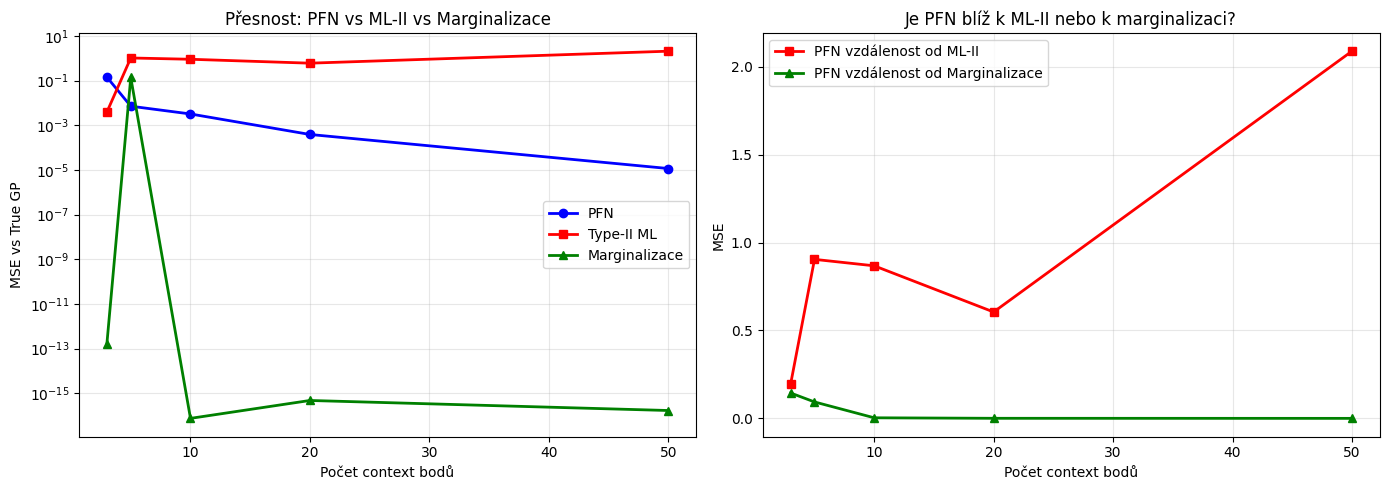

In [40]:
# =============================================
# EXPERIMENT 10: Ambiguita — marginalizace vs point estimate
# =============================================
# Málo dat → více HP je konzistentních s daty.
# Dělá PFN průměr přes HP (marginalizace), nebo vybere jedno?
# Porovnáme s GP(Type-II ML) a průměrem GP přes grid LS.

def test_ambiguity(model, true_ls=0.3, context_sizes=[3, 5, 10, 20, 50],
                   n_trials=10, ls_grid=np.linspace(0.05, 1.0, 30)):
    results = []

    for n_ctx in context_sizes:
        pfn_preds_all = []
        ml2_preds_all = []
        marginal_preds_all = []
        gp_true_preds_all = []

        for trial in range(n_trials):
            hps_test = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": true_ls}
            batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1,
                                      hyperparameters=hps_test)
            train_x = batch.x[0, :n_ctx]
            train_y = batch.y[0, :n_ctx]
            test_x = batch.x[0]

            train_x_np = train_x.cpu().numpy()
            train_y_np = train_y.cpu().numpy()
            test_x_np = test_x.cpu().numpy()

            # PFN
            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            # GP(true) — oracle
            kernel_true = ConstantKernel(1.0) * RBF(length_scale=true_ls)
            gp_true = GaussianProcessRegressor(kernel=kernel_true, alpha=1e-3)
            gp_true.fit(train_x_np, train_y_np)
            gp_true_pred = gp_true.predict(test_x_np)

            # Type-II ML — point estimate
            kernel_ml = ConstantKernel(1.0, (0.01, 10.0)) * RBF(0.3, (0.01, 5.0))
            gp_ml = GaussianProcessRegressor(kernel=kernel_ml, n_restarts_optimizer=3)
            gp_ml.fit(train_x_np, train_y_np)
            ml2_pred = gp_ml.predict(test_x_np)

            # Marginalizace — průměr GP predikcí přes grid LS (rovnoměrné váhy)
            gp_preds_grid = []
            for ls_c in ls_grid:
                kernel_c = ConstantKernel(1.0) * RBF(length_scale=ls_c)
                gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-3)
                gp_c.fit(train_x_np, train_y_np)
                gp_preds_grid.append(gp_c.predict(test_x_np))
            marginal_pred = np.mean(gp_preds_grid, axis=0)

            pfn_preds_all.append(pfn_pred)
            ml2_preds_all.append(ml2_pred)
            marginal_preds_all.append(marginal_pred)
            gp_true_preds_all.append(gp_true_pred)

        # MSE průměry
        mse_pfn = np.mean([np.mean((p - g)**2) for p, g in zip(pfn_preds_all, gp_true_preds_all)])
        mse_ml2 = np.mean([np.mean((p - g)**2) for p, g in zip(ml2_preds_all, gp_true_preds_all)])
        mse_marg = np.mean([np.mean((p - g)**2) for p, g in zip(marginal_preds_all, gp_true_preds_all)])

        # Je PFN blíž k marginalizaci nebo k point estimate?
        mse_pfn_vs_ml2 = np.mean([np.mean((p - m)**2) for p, m in zip(pfn_preds_all, ml2_preds_all)])
        mse_pfn_vs_marg = np.mean([np.mean((p - m)**2) for p, m in zip(pfn_preds_all, marginal_preds_all)])

        results.append({
            'n_context': n_ctx,
            'mse_pfn_vs_true': mse_pfn,
            'mse_ml2_vs_true': mse_ml2,
            'mse_marg_vs_true': mse_marg,
            'mse_pfn_vs_ml2': mse_pfn_vs_ml2,
            'mse_pfn_vs_marg': mse_pfn_vs_marg,
        })
        print(f"n_ctx={n_ctx:3d}: PFN={mse_pfn:.5f}, ML-II={mse_ml2:.5f}, "
              f"Marginal={mse_marg:.5f} | PFN~ML2={mse_pfn_vs_ml2:.5f}, PFN~Marg={mse_pfn_vs_marg:.5f}")

    # Vizualizace
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    n_vals = [r['n_context'] for r in results]

    ax = axes[0]
    ax.plot(n_vals, [r['mse_pfn_vs_true'] for r in results], 'o-', lw=2, label='PFN', color='blue')
    ax.plot(n_vals, [r['mse_ml2_vs_true'] for r in results], 's-', lw=2, label='Type-II ML', color='red')
    ax.plot(n_vals, [r['mse_marg_vs_true'] for r in results], '^-', lw=2, label='Marginalizace', color='green')
    ax.set_xlabel('Počet context bodů')
    ax.set_ylabel('MSE vs True GP')
    ax.set_title('Přesnost: PFN vs ML-II vs Marginalizace')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    ax.plot(n_vals, [r['mse_pfn_vs_ml2'] for r in results], 's-', lw=2,
            label='PFN vzdálenost od ML-II', color='red')
    ax.plot(n_vals, [r['mse_pfn_vs_marg'] for r in results], '^-', lw=2,
            label='PFN vzdálenost od Marginalizace', color='green')
    ax.set_xlabel('Počet context bodů')
    ax.set_ylabel('MSE')
    ax.set_title('Je PFN blíž k ML-II nebo k marginalizaci?')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results


print("=" * 60)
print("EXPERIMENT 10: Ambiguita — marginalizace vs point estimate")
print("=" * 60)
results_10d = test_ambiguity(loaded_model)

EXPERIMENT 11: Attention patterny jako funkce lengthscale


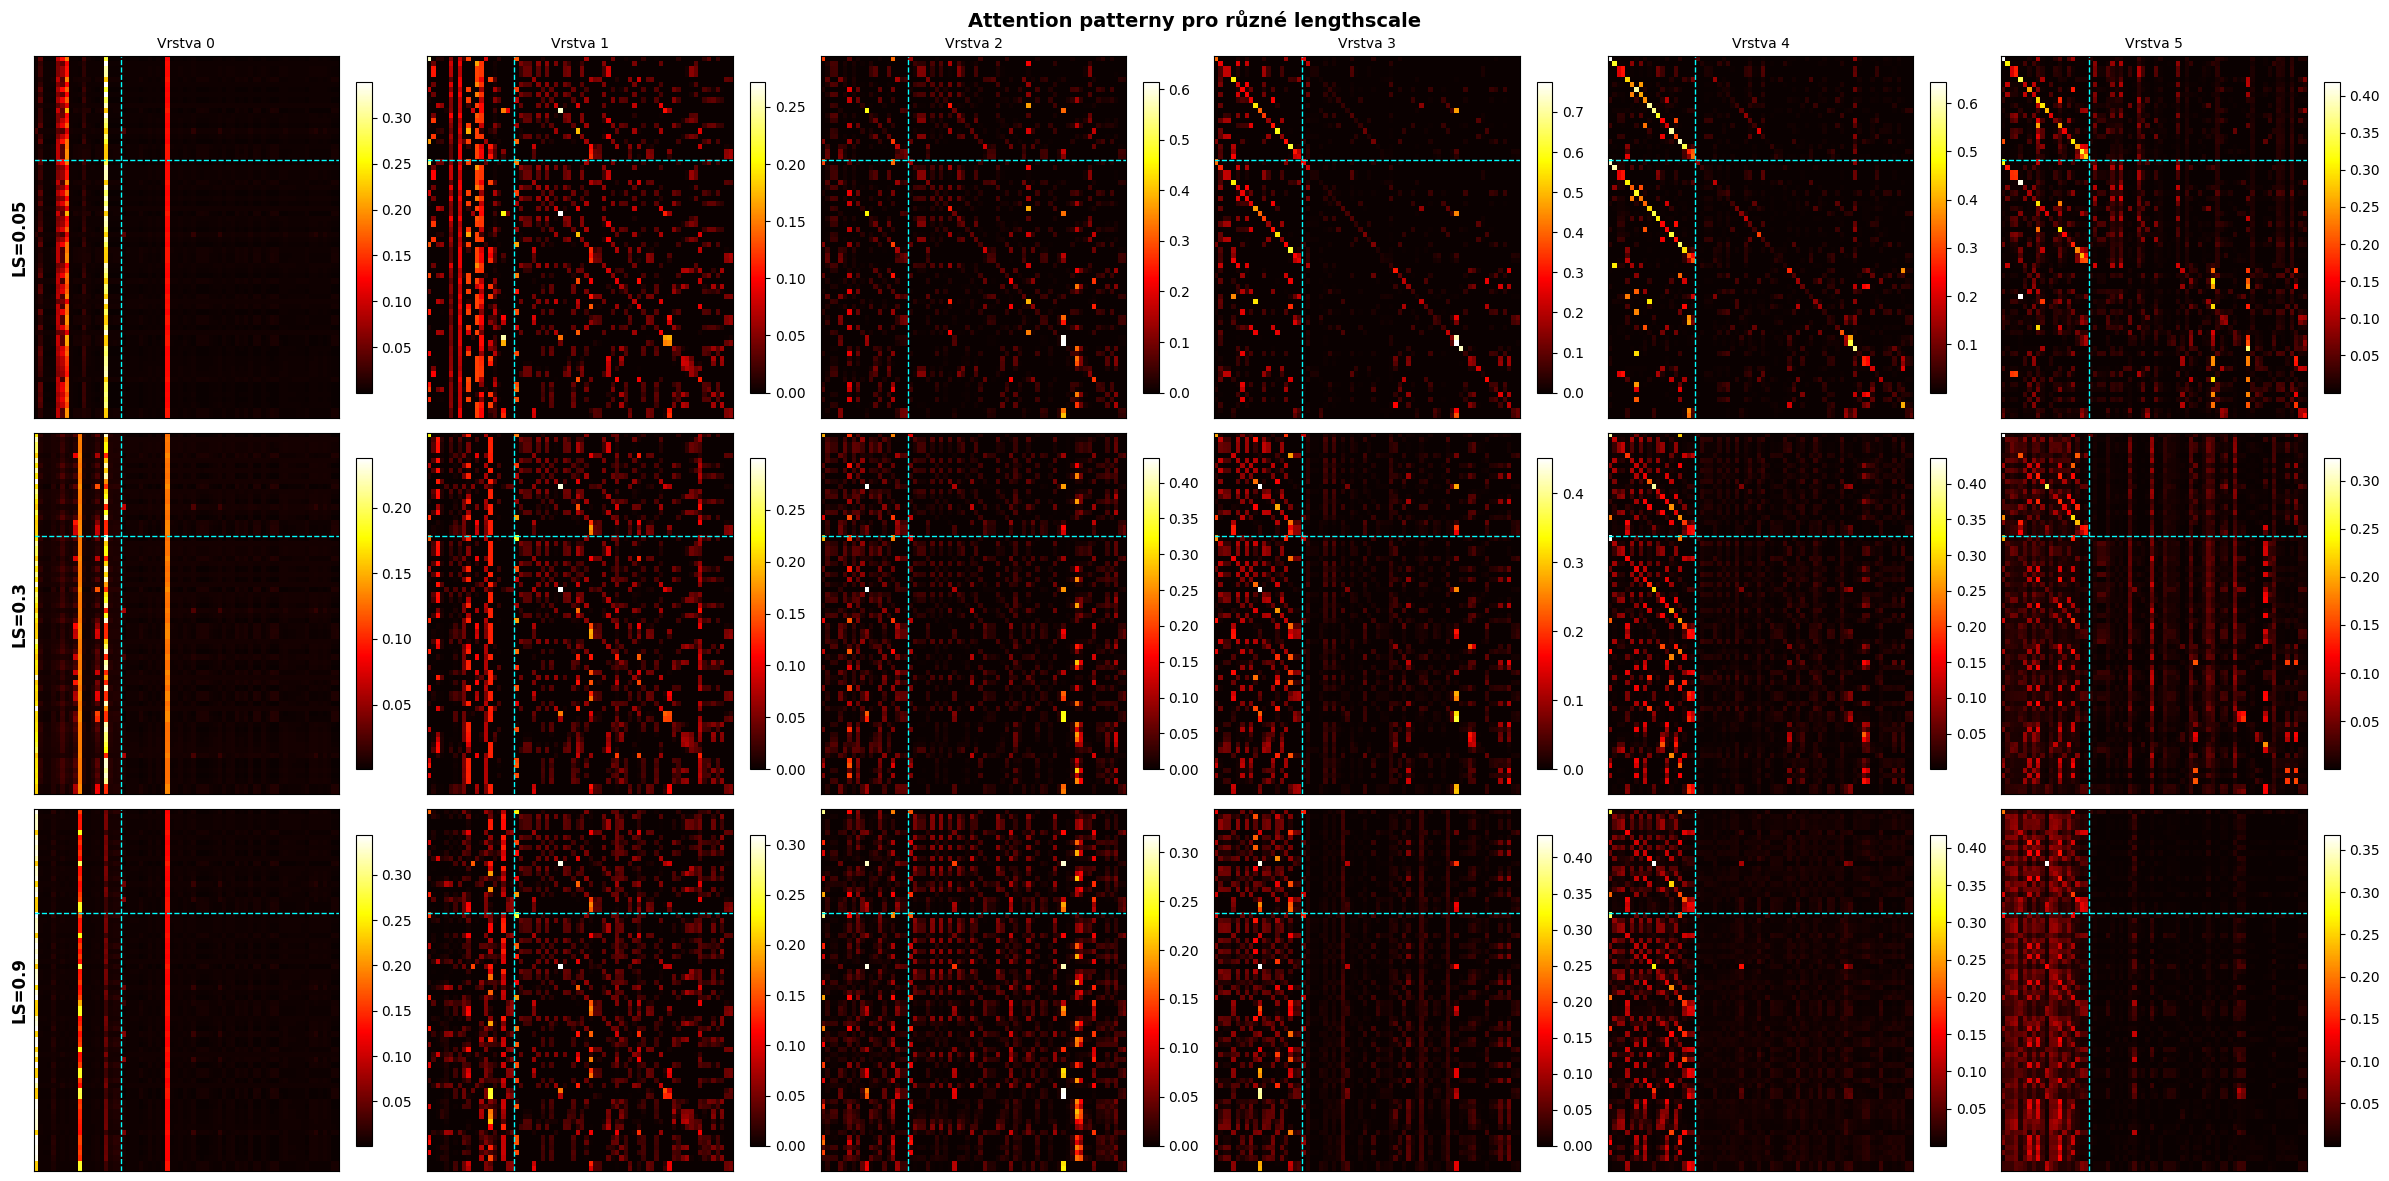


Entropie attention (vyšší = distribuovanější):
LS      Vrstva 0    Vrstva 1    Vrstva 2    Vrstva 3    Vrstva 4    Vrstva 5    
0.05    2.763       2.711       2.549       1.971       2.197       2.953       
0.30    3.021       2.861       2.957       2.800       3.118       3.517       
0.90    2.854       2.980       3.095       3.116       3.432       3.289       


In [41]:
# =============================================
# EXPERIMENT 11: Attention patterny jako funkce lengthscale
# =============================================

def test_attention_vs_lengthscale(model, lengthscales=[0.05, 0.3, 0.9],
                                   n_context=20, seq_len=50):
    fig, axes = plt.subplots(len(lengthscales), 6, figsize=(24, 4*len(lengthscales)))

    for row, ls in enumerate(lengthscales):
        hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": ls}
        batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1, hyperparameters=hps_test)
        train_x = batch.x[0, :n_context]
        train_y = batch.y[0, :n_context]
        test_x = batch.x[0]

        attn_weights_all, _ = compute_attention_weights(model, train_x, train_y, test_x)

        for col in range(min(6, len(attn_weights_all))):
            attn_layer = attn_weights_all[col][0, 0].mean(dim=0).detach().numpy()
            ax = axes[row, col]
            im = ax.imshow(attn_layer, cmap='hot', aspect='auto')
            ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=1)
            ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=1)
            if row == 0:
                ax.set_title(f'Vrstva {col}', fontsize=10)
            if col == 0:
                ax.set_ylabel(f'LS={ls}', fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle('Attention patterny pro různé lengthscale', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nEntropie attention (vyšší = distribuovanější):")
    print(f"{'LS':<8}", end='')
    for l in range(6):
        print(f"{'Vrstva '+str(l):<12}", end='')
    print()

    for ls in lengthscales:
        hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": ls}
        batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1, hyperparameters=hps_test)
        attn_all, _ = compute_attention_weights(
            model, batch.x[0, :n_context], batch.y[0, :n_context], batch.x[0])
        print(f"{ls:<8.2f}", end='')
        for col in range(min(6, len(attn_all))):
            attn = attn_all[col][0, 0].mean(dim=0).detach()
            entropy = -torch.sum(attn * torch.log(attn + 1e-10), dim=-1).mean().item()
            print(f"{entropy:<12.3f}", end='')
        print()


print("=" * 60)
print("EXPERIMENT 11: Attention patterny jako funkce lengthscale")
print("=" * 60)
test_attention_vs_lengthscale(loaded_model)

EXPERIMENT 12: Vizuální porovnání predikcí


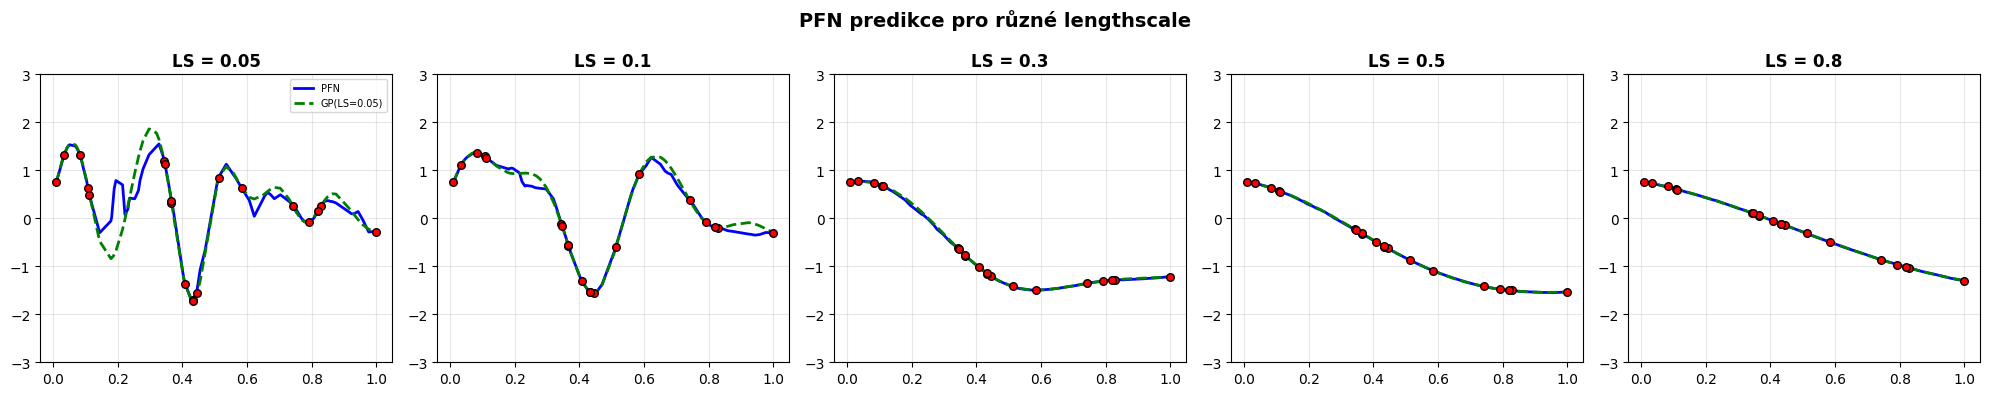

In [42]:
# =============================================
# EXPERIMENT 12: Vizuální porovnání predikcí pro různé LS
# =============================================

def visualize_predictions_across_lengthscales(model,
                                               lengthscales=[0.05, 0.1, 0.3, 0.5, 0.8],
                                               n_context=20):
    fig, axes = plt.subplots(1, len(lengthscales), figsize=(4*len(lengthscales), 4))

    for idx, ls in enumerate(lengthscales):
        hps_test = {"noise": 1e-4, "outputscale": 1.0, "lengthscale": ls}
        batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps_test)
        train_x = batch.x[0, :n_context]
        train_y = batch.y[0, :n_context]
        test_x = batch.x[0]

        with torch.no_grad():
            logits = model(train_x[None], train_y[None], test_x[None])
        pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

        kernel_c = ConstantKernel(1.0) * RBF(length_scale=ls)
        gp_c = GaussianProcessRegressor(kernel=kernel_c, alpha=1e-4)
        gp_c.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_pred_c = gp_c.predict(test_x.cpu().numpy())

        order = test_x[:, 0].cpu().argsort()
        test_sorted = test_x[order, 0].cpu().numpy()

        ax = axes[idx]
        ax.scatter(train_x[:, 0].cpu(), train_y.cpu(), c='red', s=30, zorder=10, edgecolors='black')
        ax.plot(test_sorted, pfn_pred[order], 'b-', lw=2, label='PFN')
        ax.plot(test_sorted, gp_pred_c[order], 'g--', lw=2, label=f'GP(LS={ls})')
        ax.set_title(f'LS = {ls}', fontweight='bold')
        ax.set_ylim(-3, 3)
        if idx == 0:
            ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('PFN predikce pro různé lengthscale', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("=" * 60)
print("EXPERIMENT 12: Vizuální porovnání predikcí")
print("=" * 60)
visualize_predictions_across_lengthscales(loaded_model)

# Závěr

Zde shrň výsledky všech experimentů.